# Predicting Customer recommendations Uganda’s Telecommunications
> *Sector: A Machine Learning Approach for Data-Driven
Retention Strategies*

> 1. Bisimbeko Remmy - J24M19/011

#### Supervisor: Dr. Bitalo

## Problem Statement
Uganda’s telecommunications sector suffers from high rates of customer churn, leading to significant revenue loss and increased operational costs associated with customer acquisition and retention efforts (Kabanda & Irumba, 2024). Traditional methods of analyzing churn areoften reactive and lack the precision needed to implement timely interventions (Li et al.,2021). The absence of predictive, data-driven insights limits the ability of telecom operators to understand customer behavior deeply and act before churn occurs (Matellio, 2024). There is therefore an urgent need for a reliable, data-driven predictive model that can assisttelecom companies in identifying at-risk customers and developing targeted strategies to reduce churn.


## Relevance
Ugandan telecom operators need to use proactive data-driven strategies to succeed in their competition in a saturated market environment. Decision trees and logistic regression models from machine learning offer the potential to detect customers who are at risk before they leave the company.

## Justification for AI/ML Use
Current research demonstrates global telecom industries how decision trees and logistic regression and random forests deliver optimal results in customer retention forecasting due to their ability to find non-linear behavioural patterns (Jain et al., 2021). The analysis utilises SMOTE and other methods to handle data imbalance found in drown rate assessments.

## Existing Solutions & Research Gaps
Research into churn prediction extends globally (Benghabrit et al., 2024) but few studies analyse the specific market dynamics of Uganda such as its limited infrastructure and economic conditions. The research bridges this knowledge gap through the analysis of dataset information from a Ugandan telecom operator to build prediction models specific to the Ugandan market.

In [96]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn openpyxl statsmodels imbalanced-learn xgboost fastparquet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
# Importing relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# plt.rcParams['font.family'] = 'Liberation Sans'
# plt.rcParams['font.size'] = 14
# plt.rcParams['axes.titlesize'] = 20
# plt.rcParams['axes.labelsize'] = 14
# plt.rcParams['xtick.labelsize'] = 12
# plt.rcParams['ytick.labelsize'] = 12
# plt.rcParams['legend.fontsize'] = 12
# plt.rcParams['figure.figsize'] = (14, 8)
# plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = '#888888'
plt.rcParams['figure.edgecolor'] = 'eeeeee'
warnings.filterwarnings('ignore')

# from google.colab import drive
# drive.mount('/content/drive')
# file_path = '/content/drive/MyDrive/telecom/TELECOM_X_DATASET.xlsx'
file_path = 'TELECOM_X_DATASET-original.xlsx'

# Exploratory Data Analysis

In [99]:

# Load Excel file
xls = pd.ExcelFile(file_path)

# Combine all sheets with a GEN_TYPE column 
dfs = []
for sheet in xls.sheet_names:
    df = xls.parse(sheet)
    df['GEN_TYPE'] = sheet
    dfs.append(df)

# Concatenate all into one DataFrame
original_data = pd.concat(dfs, ignore_index=True)

# Inspect data
original_data.head(100)

,PHONE_NUMBER,MANUFACTURER,MODEL_NAME,DEVICE_TYPE,HANDSET_TYPE,LOCATION,latitude,longitude,GENDER,GROSSADD,...,voicepayg,datapayg,smspayg,voicebundlerevenue,databundlerevenue,smsbundlerevenue,CALLS,SMSS,MBS,GEN_TYPE
0,15753521664,Itel,IT2160,Phone,2G,IGANGA-AIRTEL,0.62937,33.49001,F,0,...,0,0,0,0.0,0.0,0.0,[NULL],[NULL],0,2GF
1,15753678592,Itel,IT2160,Phone,2G,BULANGIRA,1.109931,33.861108,F,0,...,0,0,0,0.0,0.0,0.0,[NULL],[NULL],[NULL],2GF
2,15753851904,Bontel,L400,Phone,2G,KYANKOWE,0.388625,32.149202,F,0,...,41920,0,0,87753.6,103988.8,257.6,116,32,12328,2GF
3,15754213376,Itel,IT2160,Phone,2G,RWENTUHA,-0.556165,30.275693,F,0,...,1922544,0,0,680472.0,247478.4,8049.6,3588,936,0,2GF
4,15754528256,Itel,IT2163,Phone,2G,ATC_KATADDE,0.460332,32.566113,F,0,...,0,0,0,0.0,0.0,0.0,[NULL],[NULL],[NULL],2GF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,15780890112,Itel,IT5027,Phone,2G,OUL_YUMBETOWN,3.46961,31.2473,F,0,...,400,0,0,0.0,0.0,0.0,2,[NULL],[NULL],2GF
96,15781001472,Itel,IT2163,Phone,2G,ATC_NABISEGO,0.869196,33.600818,F,0,...,0,0,0,0.0,0.0,0.0,[NULL],[NULL],[NULL],2GF
97,15781617408,Itel,IT2163,Phone,2G,NYAMIRAMI,0.073492,29.982332,F,0,...,0,0,0,0.0,0.0,0.0,[NULL],[NULL],[NULL],2GF
98,15781697024,Itel,IT2160,Phone,2G,BUKWIRI,1.145768,31.544641,F,0,...,73480,0,0,48032.8,3656.4,310.8,245,[NULL],0,2GF


In [129]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351153 entries, 0 to 2351152
Data columns (total 31 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   PHONE_NUMBER        int64 
 1   MANUFACTURER        object
 2   MODEL_NAME          object
 3   DEVICE_TYPE         object
 4   HANDSET_TYPE        object
 5   LOCATION            object
 6   latitude            object
 7   longitude           object
 8   GENDER              object
 9   GROSSADD            object
 10  Win_Backs           object
 11  Recon               object
 12  Churn_30_days       object
 13  Rec_30_Days         object
 14  Rec_90_Days         object
 15  QREC                object
 16  QREC100MBS          object
 17  AGE                 object
 18  VALUESEGMENT        object
 19  TOTAL_REVENUE       object
 20  MOBILE_MONEY        int64 
 21  voicepayg           object
 22  datapayg            object
 23  smspayg             object
 24  voicebundlerevenue  object
 25  databundlerevenue 

In [133]:
# Creating copy of original data
operational_data = original_data.copy()

# Replacing null-like strings with actual NaN
operational_data.replace(['[NULL]', 'NULL', None], np.nan, inplace=True)
operational_data.head()

,PHONE_NUMBER,MANUFACTURER,MODEL_NAME,DEVICE_TYPE,HANDSET_TYPE,LOCATION,latitude,longitude,GENDER,GROSSADD,...,voicepayg,datapayg,smspayg,voicebundlerevenue,databundlerevenue,smsbundlerevenue,CALLS,SMSS,MBS,GEN_TYPE
0,15753521664,Itel,IT2160,Phone,2G,IGANGA-AIRTEL,0.629370,33.490010,F,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,2GF
1,15753678592,Itel,IT2160,Phone,2G,BULANGIRA,1.109931,33.861108,F,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,2GF
2,15753851904,Bontel,L400,Phone,2G,KYANKOWE,0.388625,32.149202,F,0.0,...,41920.0,0.0,0.0,87753.6,103988.8,257.6,116.0,32.0,12328.0,2GF
3,15754213376,Itel,IT2160,Phone,2G,RWENTUHA,-0.556165,30.275693,F,0.0,...,1922544.0,0.0,0.0,680472.0,247478.4,8049.6,3588.0,936.0,0.0,2GF
4,15754528256,Itel,IT2163,Phone,2G,ATC_KATADDE,0.460332,32.566113,F,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,2GF


In [134]:
# Converting known numeric columns to numeric types and catergorical columns to bool
numeric_cols = [
    'MOBILE_MONEY', 'voicepayg', 'datapayg', 'smspayg', 'latitude',
    'voicebundlerevenue', 'databundlerevenue', 'smsbundlerevenue',
    'CALLS', 'SMSS', 'MBS', 'TOTAL_REVENUE', 'AGE','longitude'
]
for col in numeric_cols:
    if col in operational_data.columns:
        operational_data[col] = pd.to_numeric(operational_data[col], errors='coerce')

bool_cols = [
    'Rec_30_Days', 'Rec_90_Days', 'QREC', 'QREC100MBS', 'Recon',
    'GROSSADD', 'Win_Backs'
]
for col in bool_cols:
    if col in operational_data.columns:
        operational_data[col] = operational_data[col].astype(bool)

operational_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351153 entries, 0 to 2351152
Data columns (total 31 columns):
 #   Column              Dtype  
---  ------              -----  
 0   PHONE_NUMBER        int64  
 1   MANUFACTURER        object 
 2   MODEL_NAME          object 
 3   DEVICE_TYPE         object 
 4   HANDSET_TYPE        object 
 5   LOCATION            object 
 6   latitude            float64
 7   longitude           float64
 8   GENDER              object 
 9   GROSSADD            bool   
 10  Win_Backs           bool   
 11  Recon               bool   
 12  Churn_30_days       float64
 13  Rec_30_Days         bool   
 14  Rec_90_Days         bool   
 15  QREC                bool   
 16  QREC100MBS          bool   
 17  AGE                 float64
 18  VALUESEGMENT        object 
 19  TOTAL_REVENUE       float64
 20  MOBILE_MONEY        int64  
 21  voicepayg           float64
 22  datapayg            float64
 23  smspayg             float64
 24  voicebundlerevenue  floa

In [135]:
# Get summary statistics for numeric columns
desc = operational_data.describe(include=['float64', 'int'])
desc_formatted = desc.applymap(lambda x: f"{x:,.2f}")

# Display the formatted summary
print("📊 Human-Readable Summary of Numeric Features:\n")
display(desc_formatted)


📊 Human-Readable Summary of Numeric Features:



,PHONE_NUMBER,latitude,longitude,Churn_30_days,AGE,TOTAL_REVENUE,MOBILE_MONEY,voicepayg,datapayg,smspayg,voicebundlerevenue,databundlerevenue,smsbundlerevenue,CALLS,SMSS,MBS
count,"2,351,153.00","2,261,195.00","2,261,195.00","2,308,184.00","1,551,162.00","2,301,598.00","2,351,153.00","2,301,598.00","2,301,598.00","2,301,598.00","2,301,598.00","2,301,598.00","2,301,598.00","1,129,259.00","540,106.00","1,239,167.00"
mean,"25,461,074,807.62",0.51,32.37,0.00,35.72,"30,616,266.38","243,641.55","1,676,950.23","145,304.84","145,636.35","9,269,158.02","18,687,243.26","243,673.33","11,760.57","10,141.90","501,534.32"
std,"12,081,928,465.28",0.78,1.05,0.05,12.38,"190,632,801.12","304,372.73","43,318,113.02","22,759,526.30","4,875,765.58","59,406,569.45","124,030,364.69","5,471,469.52","47,280.15","62,215.23","2,420,963.56"
min,36.00,-1.44,29.60,0.00,-951.00,0.00,"1,500.00",0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
25%,"16,872,533,760.00",0.26,31.87,0.00,27.00,0.00,"4,825.00",0.00,0.00,0.00,0.00,0.00,0.00,84.00,140.00,6.00
50%,"26,537,593,600.00",0.36,32.56,0.00,33.00,500.00,"71,479.00",0.00,0.00,0.00,0.00,0.00,0.00,815.00,900.00,"5,708.00"
75%,"28,889,117,440.00",0.68,32.77,0.00,42.00,"2,281,234.00","444,226.00","14,352.00",0.00,0.00,"390,133.94","575,750.75",120.40,"5,652.00","4,495.00","155,280.00"
max,"89,223,423,744.00",3.80,34.95,1.00,168.00,"37,623,357,576.00","1,005,499.00","22,730,802,080.00","19,995,046,500.00","3,362,627,412.00","12,274,591,608.00","15,837,280,000.00","1,674,000,000.00","3,868,025.00","9,659,104.00","316,338,975.00"


In [136]:
operational_data.describe(include=['object', 'bool'])

,MANUFACTURER,MODEL_NAME,DEVICE_TYPE,HANDSET_TYPE,LOCATION,GENDER,GROSSADD,Win_Backs,Recon,Rec_30_Days,Rec_90_Days,QREC,QREC100MBS,VALUESEGMENT,GEN_TYPE
count,2269092,2269092,2269092,2351153,2261195,1551153,2351153,2351153,2351153,2351153,2351153,2351153,2351153,2217484,2351153
unique,1848,15753,19,4,4331,2,2,2,2,2,2,2,2,8,12
top,Itel,IT2160,Smartphone,2G,ENTEBBE AIRPORT,M,False,False,False,True,True,False,False,Ivory,2GF
freq,555813,154096,1630246,600000,26957,789297,2247744,2306268,2307036,1545337,1742383,1351854,1555548,776653,200000


In [137]:
# Inspecting Duplicates
print(f"Number of duplicated rows: {operational_data.duplicated().sum()}")
duplicates = operational_data.duplicated()
# Show the duplicated rows
operational_data[duplicates]

Number of duplicated rows: 0


,PHONE_NUMBER,MANUFACTURER,MODEL_NAME,DEVICE_TYPE,HANDSET_TYPE,LOCATION,latitude,longitude,GENDER,GROSSADD,...,voicepayg,datapayg,smspayg,voicebundlerevenue,databundlerevenue,smsbundlerevenue,CALLS,SMSS,MBS,GEN_TYPE


In [138]:
# Total rows and missing target values
total_rows = operational_data.shape[0]
missing_target = operational_data['Churn_30_days'].isna().sum()
percent_missing = (missing_target / total_rows) * 100

print(f"Total rows: {total_rows:,}")
print(f"Missing target rows: {missing_target:,}")
print(f"Percentage missing: {percent_missing:.2f}%")

Total rows: 2,351,153
Missing target rows: 42,969
Percentage missing: 1.83%


In [139]:
# Dropping rows with no churn info (target)
# operational_data = operational_data.dropna(subset=['Churn_30_days'])

# Converting target column to binary
# operational_data['Churn_30_days'] = operational_data['Churn_30_days'].astype(bool)

# Renaming Operational Data Columns
operational_data.columns = ['Phone_Number', 'Manufacturer', 'Model_Name', 'Device_Type',
       'Handset_Type', 'Location', 'Latitude', 'Longitude', 'Gender',
       'Gross_Add', 'Win_Backs', 'Recon', 'Churn_30_days', 'REC_30_Days',
       'REC_90_Days', 'Q_Rec', 'Q_Rec_over100mbs', 'Age', 'Value_Segment',
       'Tot_Revenue', 'Mobile_Money', 'Voice_PAYG', 'Data_PAYG', 'SMS_PAYG',
       'Voice_Bundle_Rev', 'Data_Bundle_Rev', 'SMS_Bundle_Rev', 'Calls',
       'SMS', 'Mbs', 'Net_Generation']
operational_data.head()

,Phone_Number,Manufacturer,Model_Name,Device_Type,Handset_Type,Location,Latitude,Longitude,Gender,Gross_Add,...,Voice_PAYG,Data_PAYG,SMS_PAYG,Voice_Bundle_Rev,Data_Bundle_Rev,SMS_Bundle_Rev,Calls,SMS,Mbs,Net_Generation
0,15753521664,Itel,IT2160,Phone,2G,IGANGA-AIRTEL,0.629370,33.490010,F,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,2GF
1,15753678592,Itel,IT2160,Phone,2G,BULANGIRA,1.109931,33.861108,F,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,2GF
2,15753851904,Bontel,L400,Phone,2G,KYANKOWE,0.388625,32.149202,F,False,...,41920.0,0.0,0.0,87753.6,103988.8,257.6,116.0,32.0,12328.0,2GF
3,15754213376,Itel,IT2160,Phone,2G,RWENTUHA,-0.556165,30.275693,F,False,...,1922544.0,0.0,0.0,680472.0,247478.4,8049.6,3588.0,936.0,0.0,2GF
4,15754528256,Itel,IT2163,Phone,2G,ATC_KATADDE,0.460332,32.566113,F,False,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,2GF


In [140]:
# Exploring missing values in other variables
missing_info = operational_data.isna().sum().to_frame(name = 'Missing_Count')
missing_info['Percentage %'] = (missing_info['Missing_Count'] / len(operational_data)) * 100
missing_info = missing_info[missing_info['Missing_Count']>0].sort_values(by='Missing_Count', ascending=False)
missing_info

,Missing_Count,Percentage %
SMS,1811047,77.028037
Calls,1221894,51.969991
Mbs,1111986,47.295348
Gender,800000,34.025859
Age,799991,34.025476
Value_Segment,133669,5.685253
Longitude,89958,3.826123
Location,89958,3.826123
Latitude,89958,3.826123
Device_Type,82061,3.490245


In [141]:
# Dropping Location and Network Generation Columns
columns_to_drop = ['Location', 'Net_Generation']
operational_data.drop(columns = columns_to_drop, inplace = True)

# Replacing Null values in Value Segment variable with 'New' where Gross Add is 1
operational_data.loc[(operational_data["Gross_Add"] == 1) & (operational_data['Value_Segment'].isna()), 'Value_Segment'] = 0

# Replacing Null values in Calls, SMS and Mbs variables to 0
columns_to_fill = ['Calls', 'SMS', 'Mbs','Tot_Revenue', 'Mobile_Money', 'Voice_PAYG', 'Data_PAYG', 'SMS_PAYG',
       'Voice_Bundle_Rev', 'Data_Bundle_Rev', 'SMS_Bundle_Rev']

operational_data[columns_to_fill] = operational_data[columns_to_fill].fillna(0)

missing_info = operational_data.isna().sum().to_frame(name = 'Missing_Count')
missing_info['Percentage %'] = (missing_info['Missing_Count'] / len(operational_data)) * 100
missing_info = missing_info[missing_info['Missing_Count']>0].sort_values(by='Missing_Count', ascending=False)
missing_info

,Missing_Count,Percentage %
Gender,800000,34.025859
Age,799991,34.025476
Longitude,89958,3.826123
Latitude,89958,3.826123
Manufacturer,82061,3.490245
Model_Name,82061,3.490245
Device_Type,82061,3.490245
Churn_30_days,42969,1.827571
Value_Segment,31221,1.327902


In [142]:
# Replacing NaN in Gender with 'Undocumented'
operational_data['Gender'] = operational_data['Gender'].fillna('Undocumented')

# Generating age groups
def generate_age_groups(age):
    if age < 13:
        return 'Below 13'
    elif age < 20:
        return '13-19'
    elif age < 36:
        return '20-35'
    elif age < 50:
        return '36-49'
    elif age <= 65:
        return '50-65'
    elif age > 65:
        return 'Above 65'
    else:
        return'Null'

operational_data["Age_Groups"] = operational_data["Age"].apply(generate_age_groups)

In [143]:
operational_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351153 entries, 0 to 2351152
Data columns (total 30 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Phone_Number      int64  
 1   Manufacturer      object 
 2   Model_Name        object 
 3   Device_Type       object 
 4   Handset_Type      object 
 5   Latitude          float64
 6   Longitude         float64
 7   Gender            object 
 8   Gross_Add         bool   
 9   Win_Backs         bool   
 10  Recon             bool   
 11  Churn_30_days     float64
 12  REC_30_Days       bool   
 13  REC_90_Days       bool   
 14  Q_Rec             bool   
 15  Q_Rec_over100mbs  bool   
 16  Age               float64
 17  Value_Segment     object 
 18  Tot_Revenue       float64
 19  Mobile_Money      int64  
 20  Voice_PAYG        float64
 21  Data_PAYG         float64
 22  SMS_PAYG          float64
 23  Voice_Bundle_Rev  float64
 24  Data_Bundle_Rev   float64
 25  SMS_Bundle_Rev    float64
 26  Calls         

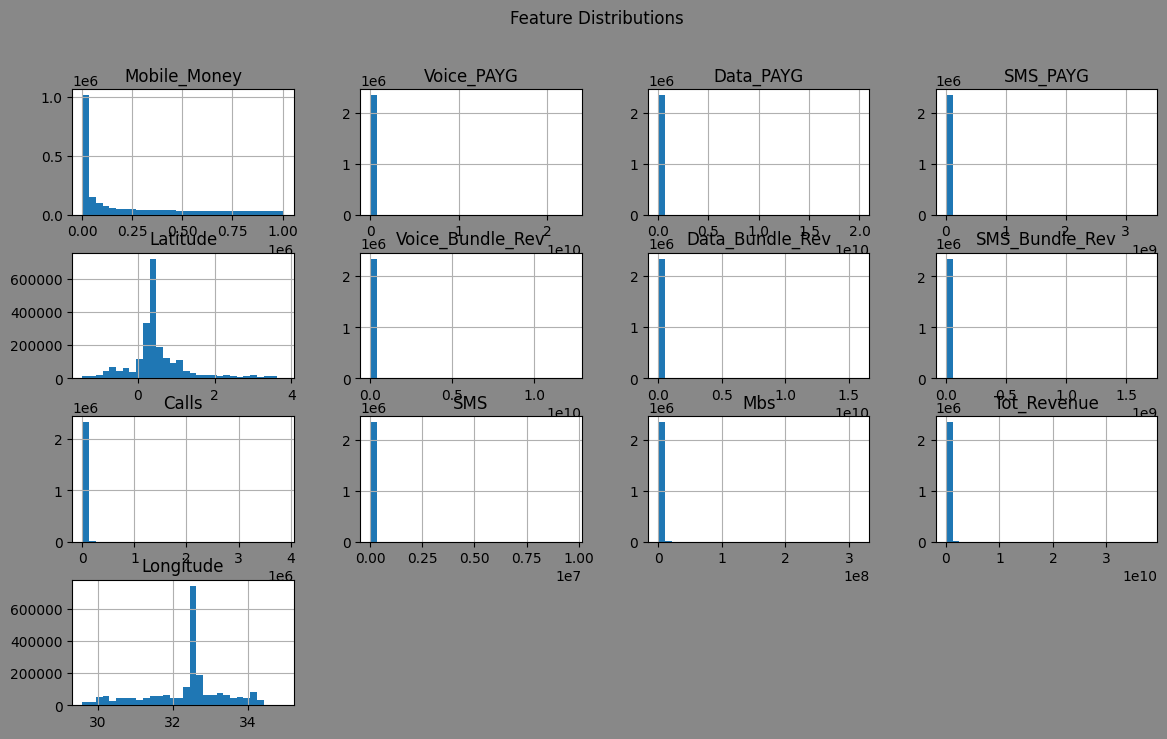

In [144]:
# List of intended numeric columns
numeric_cols = [
    'Mobile_Money', 'Voice_PAYG', 'Data_PAYG', 'SMS_PAYG',
    'Latitude', 'Voice_Bundle_Rev', 'Data_Bundle_Rev',
    'SMS_Bundle_Rev', 'Calls', 'SMS', 'Mbs',
    'Tot_Revenue', 'Longitude'
]

# Keep only the columns that actually exist in your dataset
existing_cols = [col for col in numeric_cols if col in operational_data.columns]

# Now plot only those
operational_data[existing_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Feature Distributions")
plt.show()

> The feature distribution graph reveals that most numerical variables are highly right-skewed, with the majority of customers showing minimal activity and a few extreme outliers. Age is well-distributed and normally concentrated between 20 and 50, making it a reliable input for modeling. Latitude and longitude appear to contain invalid or extreme values, indicating a need for cleaning before analysis.

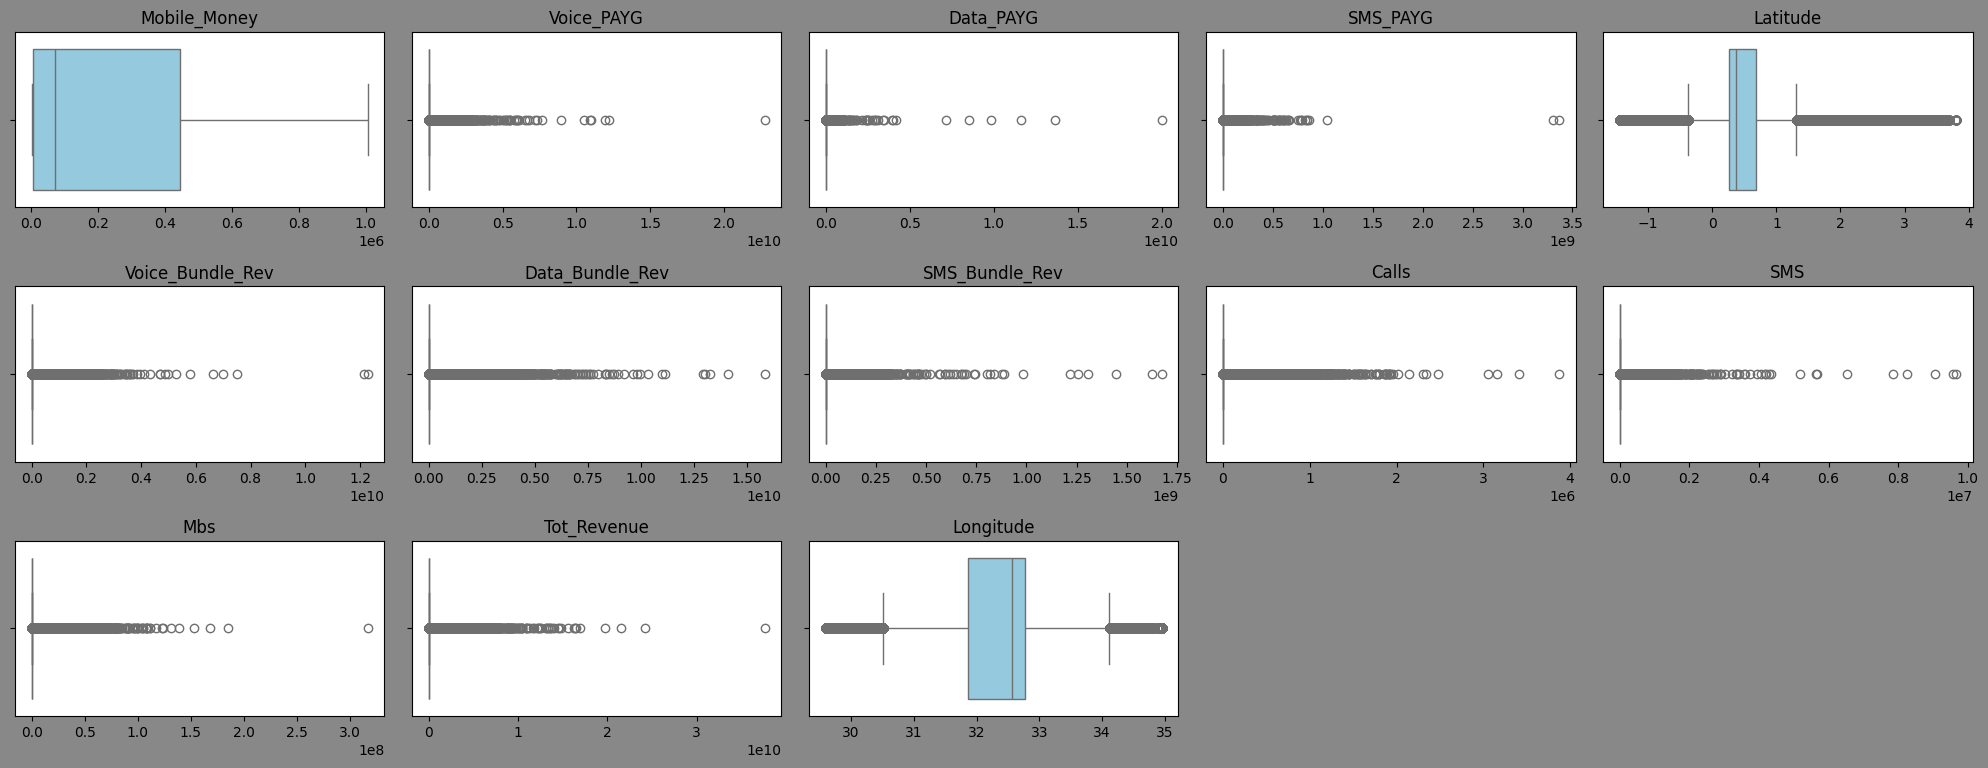

In [145]:
# Plot box plots for each continuous variable to identify outliers
plt.figure(figsize=(20, 15))
for i, var in enumerate(numeric_cols):
    plt.subplot(6, 5, i + 1)
    sns.boxplot(x=operational_data[var], color='skyblue')
    plt.title(var)
    plt.xlabel('')
plt.tight_layout()
plt.show()

> The boxplot visualization reveals significant outliers across most numeric features, especially in revenue and usage fields such as `Voice_PAYG`, `Data_Bundle_Rev`, and `Mbs`, suggesting a small group of heavy users. In contrast, features like `Age` and `Longitude` appear to have more compact and realistic distributions, though some minor outliers still exist. The presence of these outliers highlights the need for data transformation or outlier-handling techniques before modeling.

## Outlier Treatment

In [146]:
def is_good_for_iqr(df, col, std_threshold=1.0, min_unique=5):
    return df[col].std() > std_threshold and df[col].nunique() >= min_unique

def replace_outliers_with_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

def clip_outliers_percentile(df, column, lower=0.01, upper=0.99):
    lower_val = df[column].quantile(lower)
    upper_val = df[column].quantile(upper)
    df[column] = df[column].clip(lower_val, upper_val)
    return df

In [147]:
operational_data['USED_DATAPAYG'] = (operational_data['Data_PAYG'] > 0).astype(int)
operational_data['USED_SMSPAYG'] = (operational_data['SMS_PAYG'] > 0).astype(int)
operational_data['USED_SMS'] = (operational_data['SMS'] > 0).astype(int)

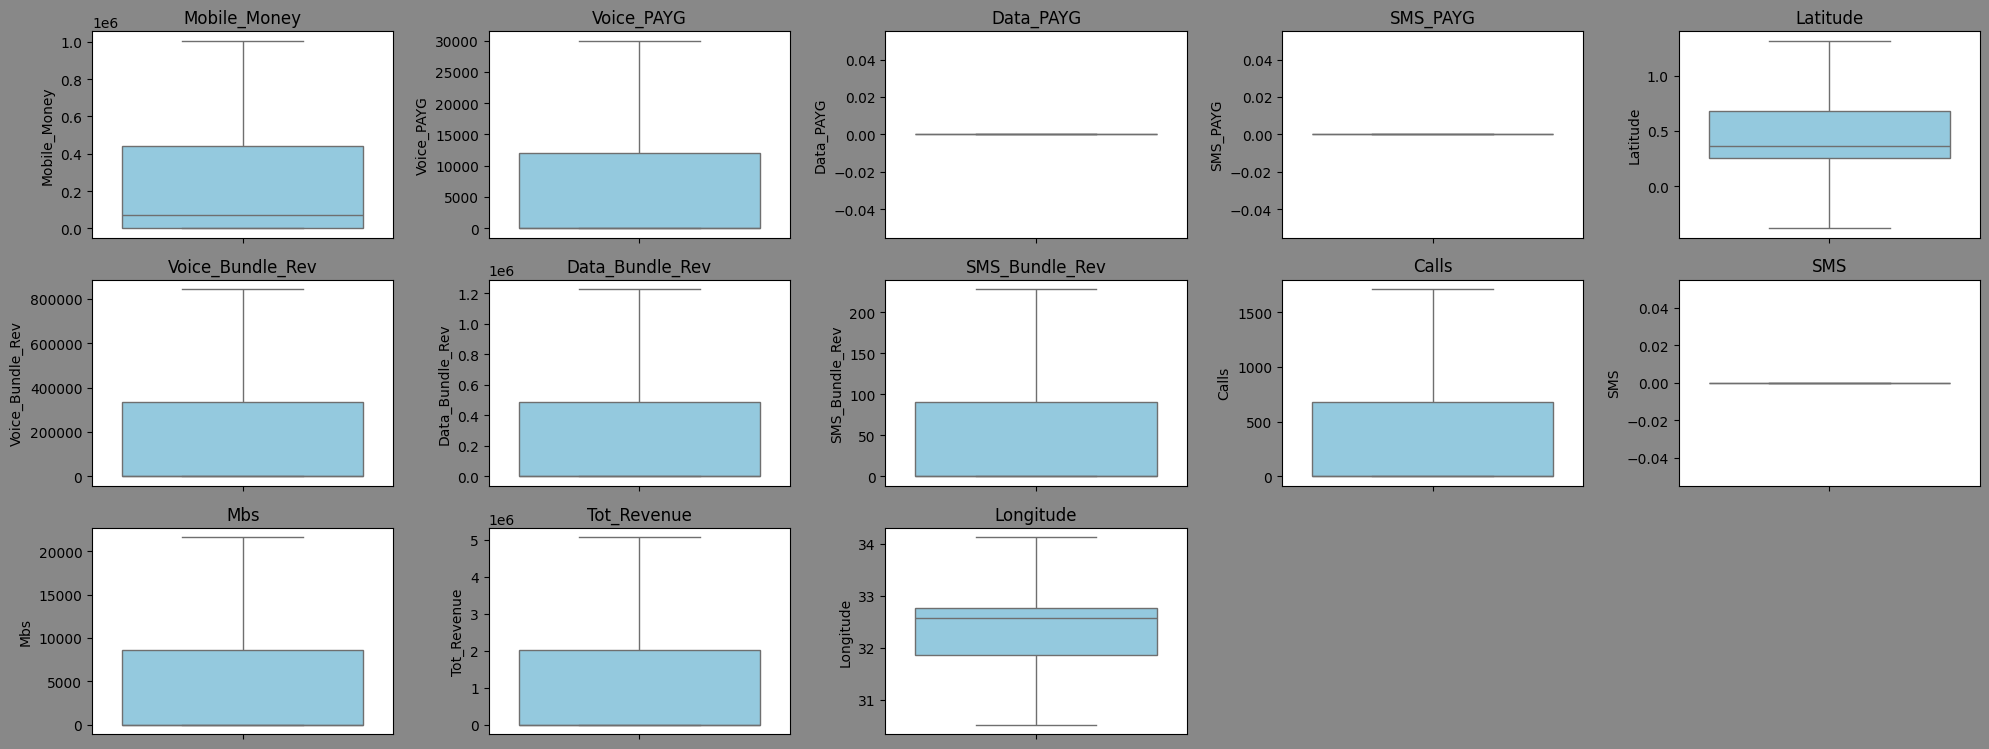

In [148]:
df_clean = pd.DataFrame()

# Plot boxplots for each continuous variable after outlier treatment
plt.figure(figsize=(20, 15))
for i, var in enumerate(numeric_cols):
    df_clean = replace_outliers_with_iqr(operational_data, var)

    # Plotting
    plt.subplot(6, 5, i+1)
    sns.boxplot(y=df_clean[var], color='skyblue')
    plt.title(var)
plt.tight_layout()
plt.show()

## Rare cases in Categorical Variables

In [149]:
categorical_cols = [
    'Manufacturer', 'Model_Name', 'Device_Type',
    'Handset_Type', 'Gender', 'Value_Segment',
    'Age_Groups', 'REC_30_Days', 'REC_90_Days',
    'Q_Rec', 'Q_Rec_over100mbs', 'Recon', 'Gross_Add',
    'Win_Backs', 'USED_DATAPAYG', 'USED_SMSPAYG', 'USED_SMS'
];

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(normalize=True) * 100)


--- Manufacturer ---
Manufacturer
Itel        24.494952
Tecno       19.236549
Samsung     18.051406
Apple        7.910301
Infinix      5.582101
              ...    
Enol         0.000044
Tiange       0.000044
Juniper      0.000044
PCD          0.000044
Franklin     0.000044
Name: proportion, Length: 1848, dtype: float64

--- Model_Name ---
Model_Name
IT2160     6.791086
ZLTX25     2.385183
IT2163     1.509150
Smart5     1.423257
A055F      1.357900
             ...   
K12Plus    0.000044
SK65       0.000044
E1205T     0.000044
N300       0.000044
A605       0.000044
Name: proportion, Length: 15753, dtype: float64

--- Device_Type ---
Device_Type
Smartphone          71.845743
Phone               23.207873
Tablet               3.281092
WLAN Router          0.715617
Modem                0.207352
IoT Device           0.206735
Dongle               0.173946
Network device       0.160990
USB modem            0.067869
Data only tablet     0.035697
Smartwatch           0.029792
Module        

In [150]:
df_clean['Device_Type'] = df_clean['Device_Type'].fillna(df_clean['Device_Type'].mode()[0])
df_clean['Model_Name'] = df_clean['Model_Name'].fillna('Fake Phone')
df_clean['Value_Segment'] = df_clean['Value_Segment'].fillna('Other')
df_clean['Manufacturer'] = df_clean['Manufacturer'].fillna(df_clean['Manufacturer'].mode()[0])

#### Replace rare categories with 'Other'

In [151]:
def replace_rare_categories(df, column, threshold=0):
    value_counts = df[column].value_counts(normalize=True) * 100
    rare_categories = value_counts[value_counts < threshold].index.tolist()
    df[column] = df[column].apply(lambda x: 'Other' if x in rare_categories else x)
    return df

In [152]:
for col in ['Manufacturer', 'Model_Name', 'Device_Type']:
    df_clean = replace_rare_categories(df_clean, col, threshold=0.5)


#### Handle missing categorical data

In [153]:
df_clean[categorical_cols].isnull().sum()

Manufacturer        0
Model_Name          0
Device_Type         0
Handset_Type        0
Gender              0
Value_Segment       0
Age_Groups          0
REC_30_Days         0
REC_90_Days         0
Q_Rec               0
Q_Rec_over100mbs    0
Recon               0
Gross_Add           0
Win_Backs           0
USED_DATAPAYG       0
USED_SMSPAYG        0
USED_SMS            0
dtype: int64

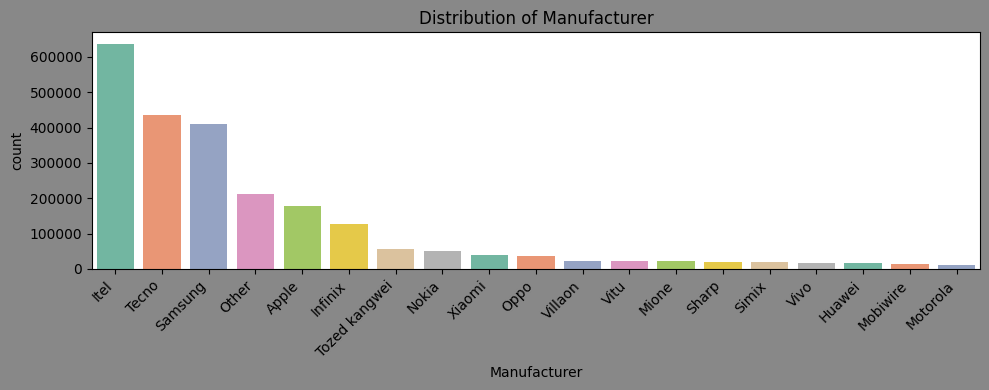

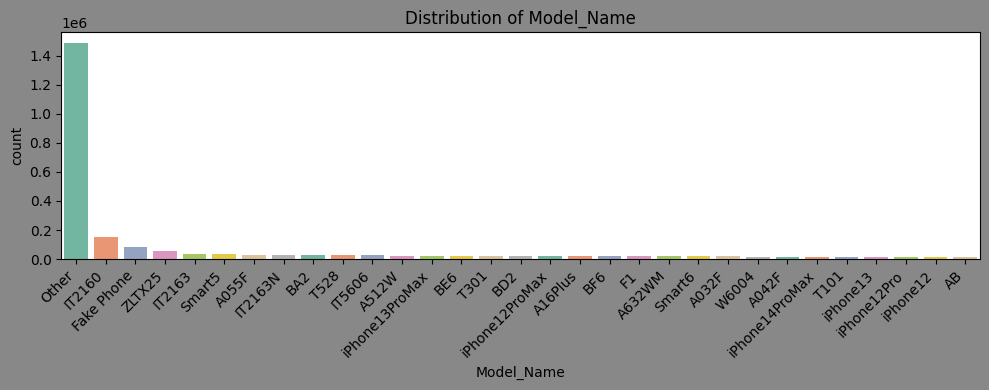

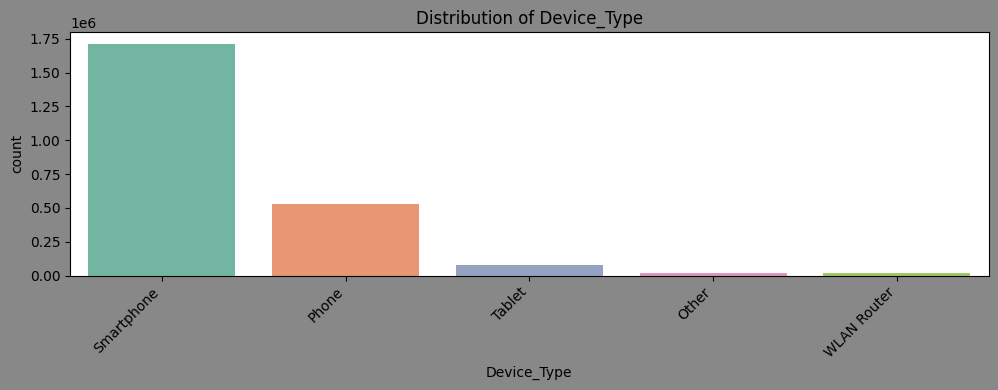

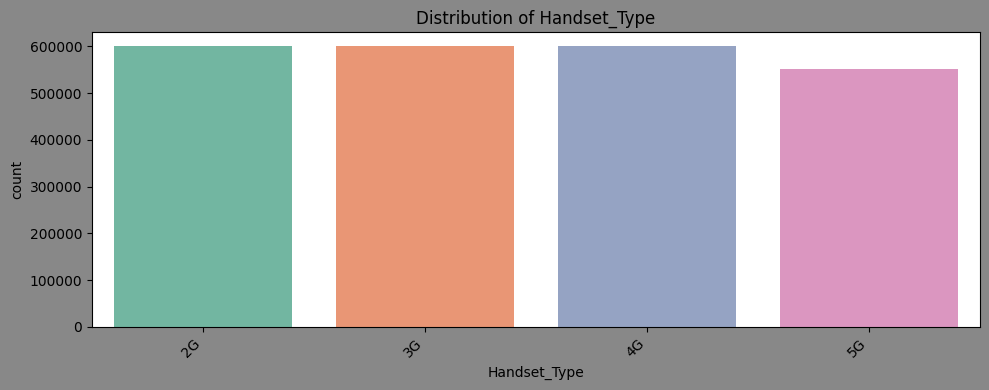

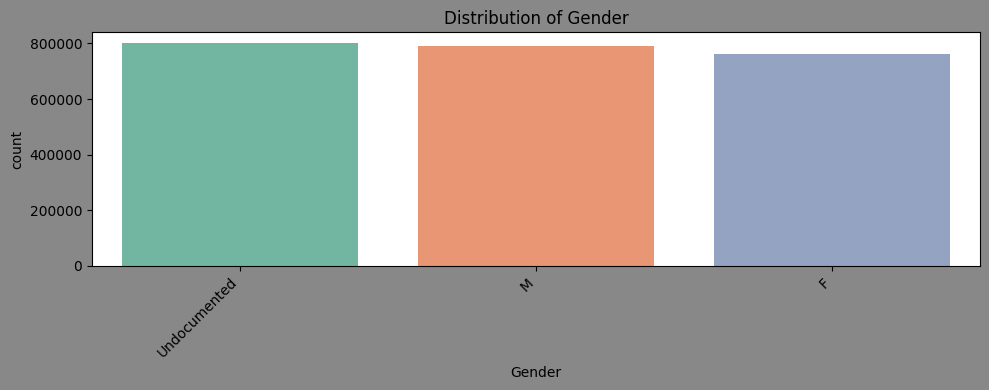

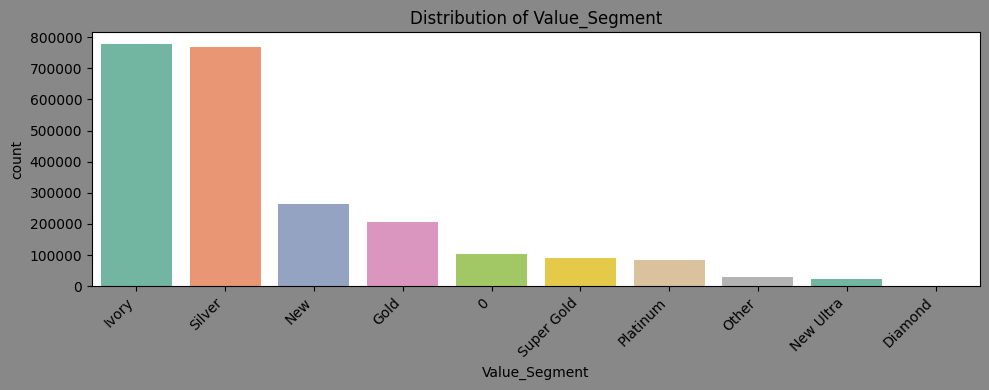

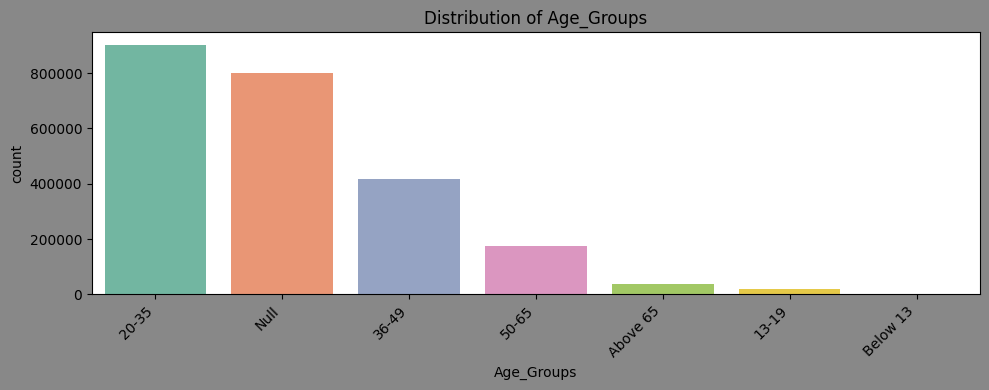

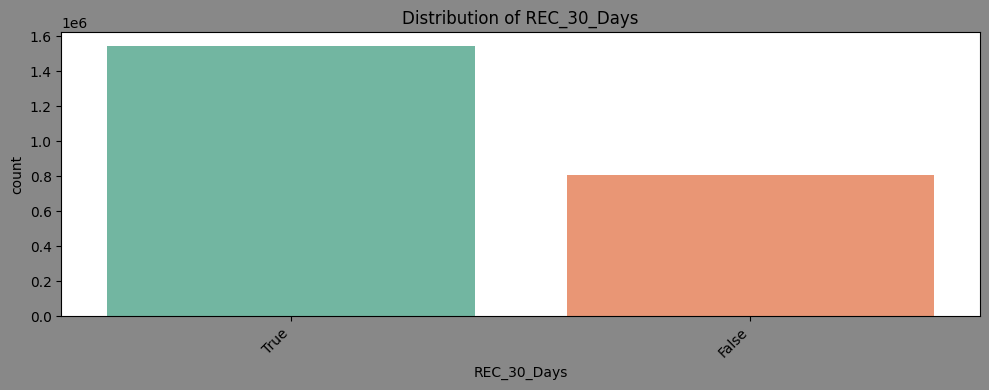

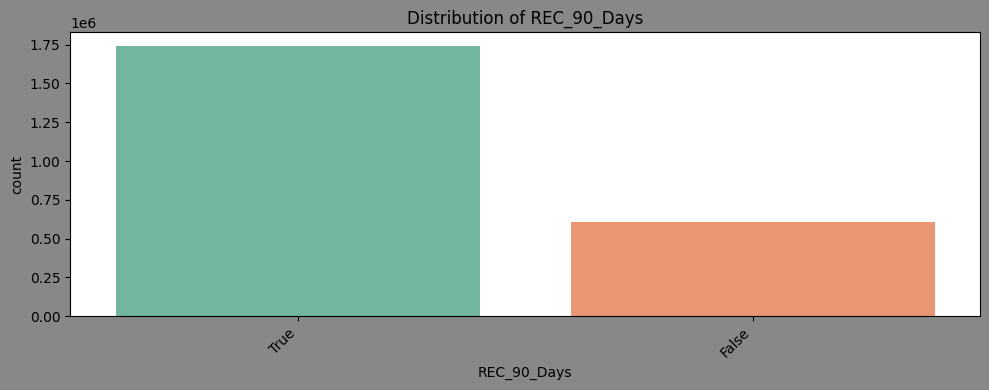

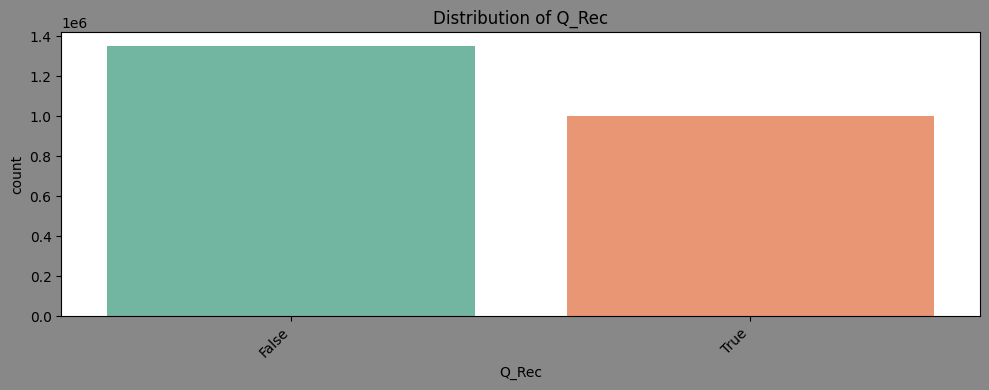

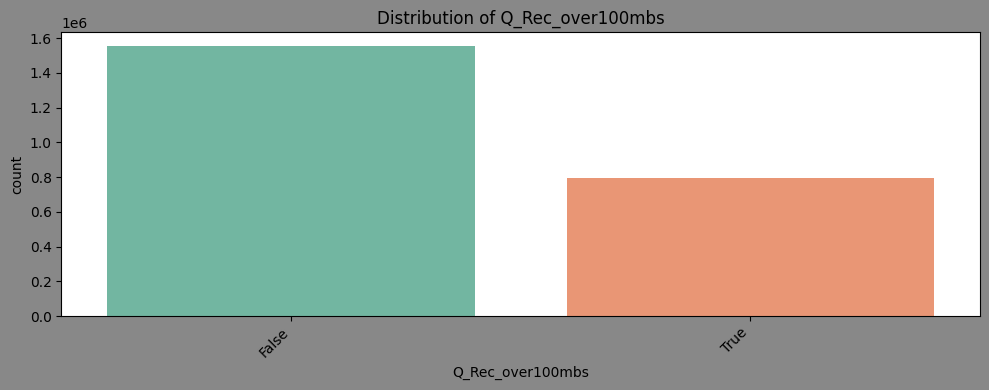

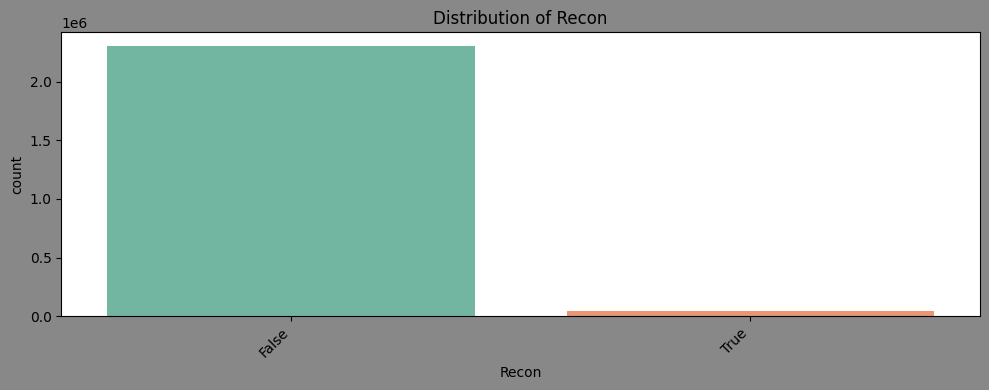

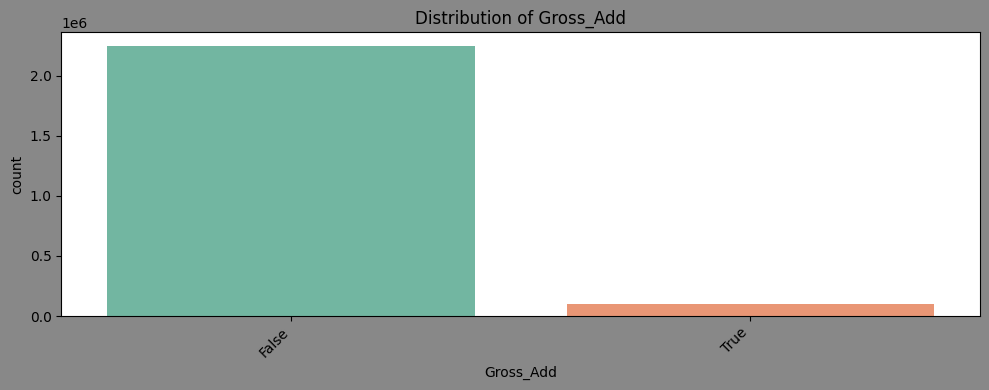

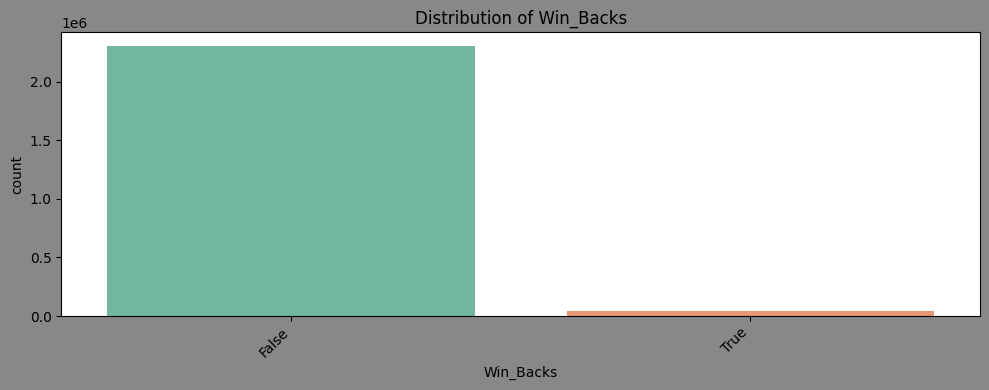

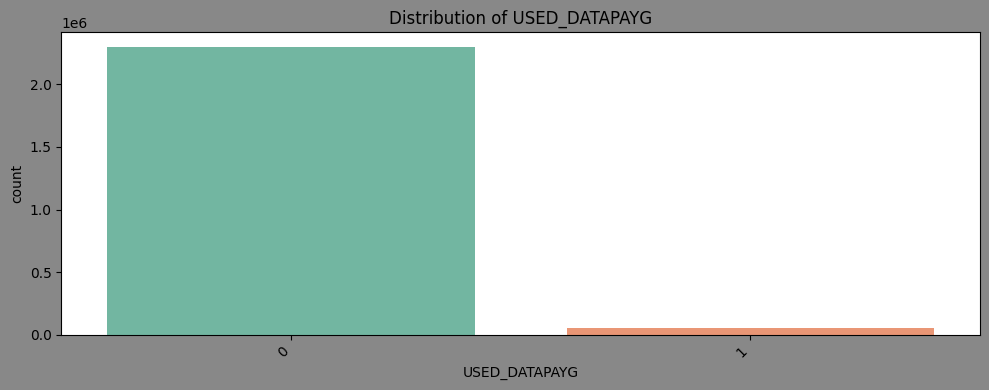

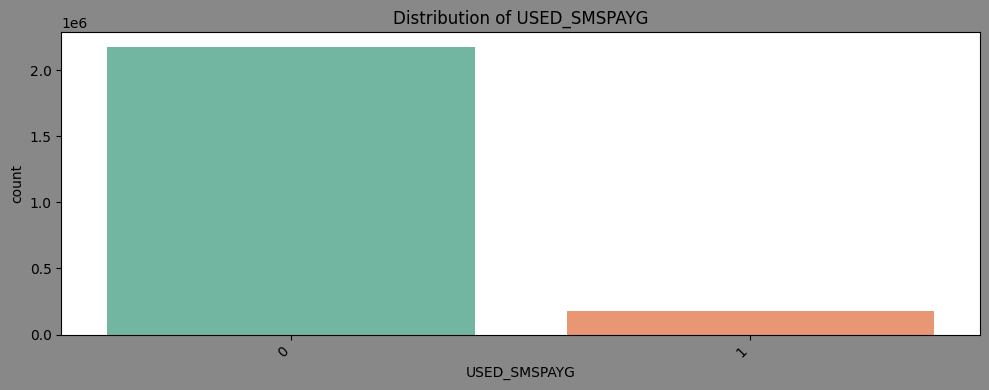

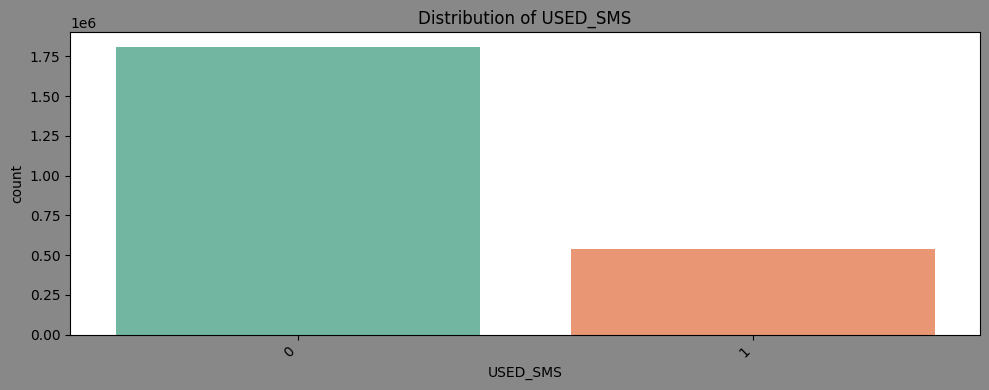

In [154]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index, palette='Set2')
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## Feature Engineering

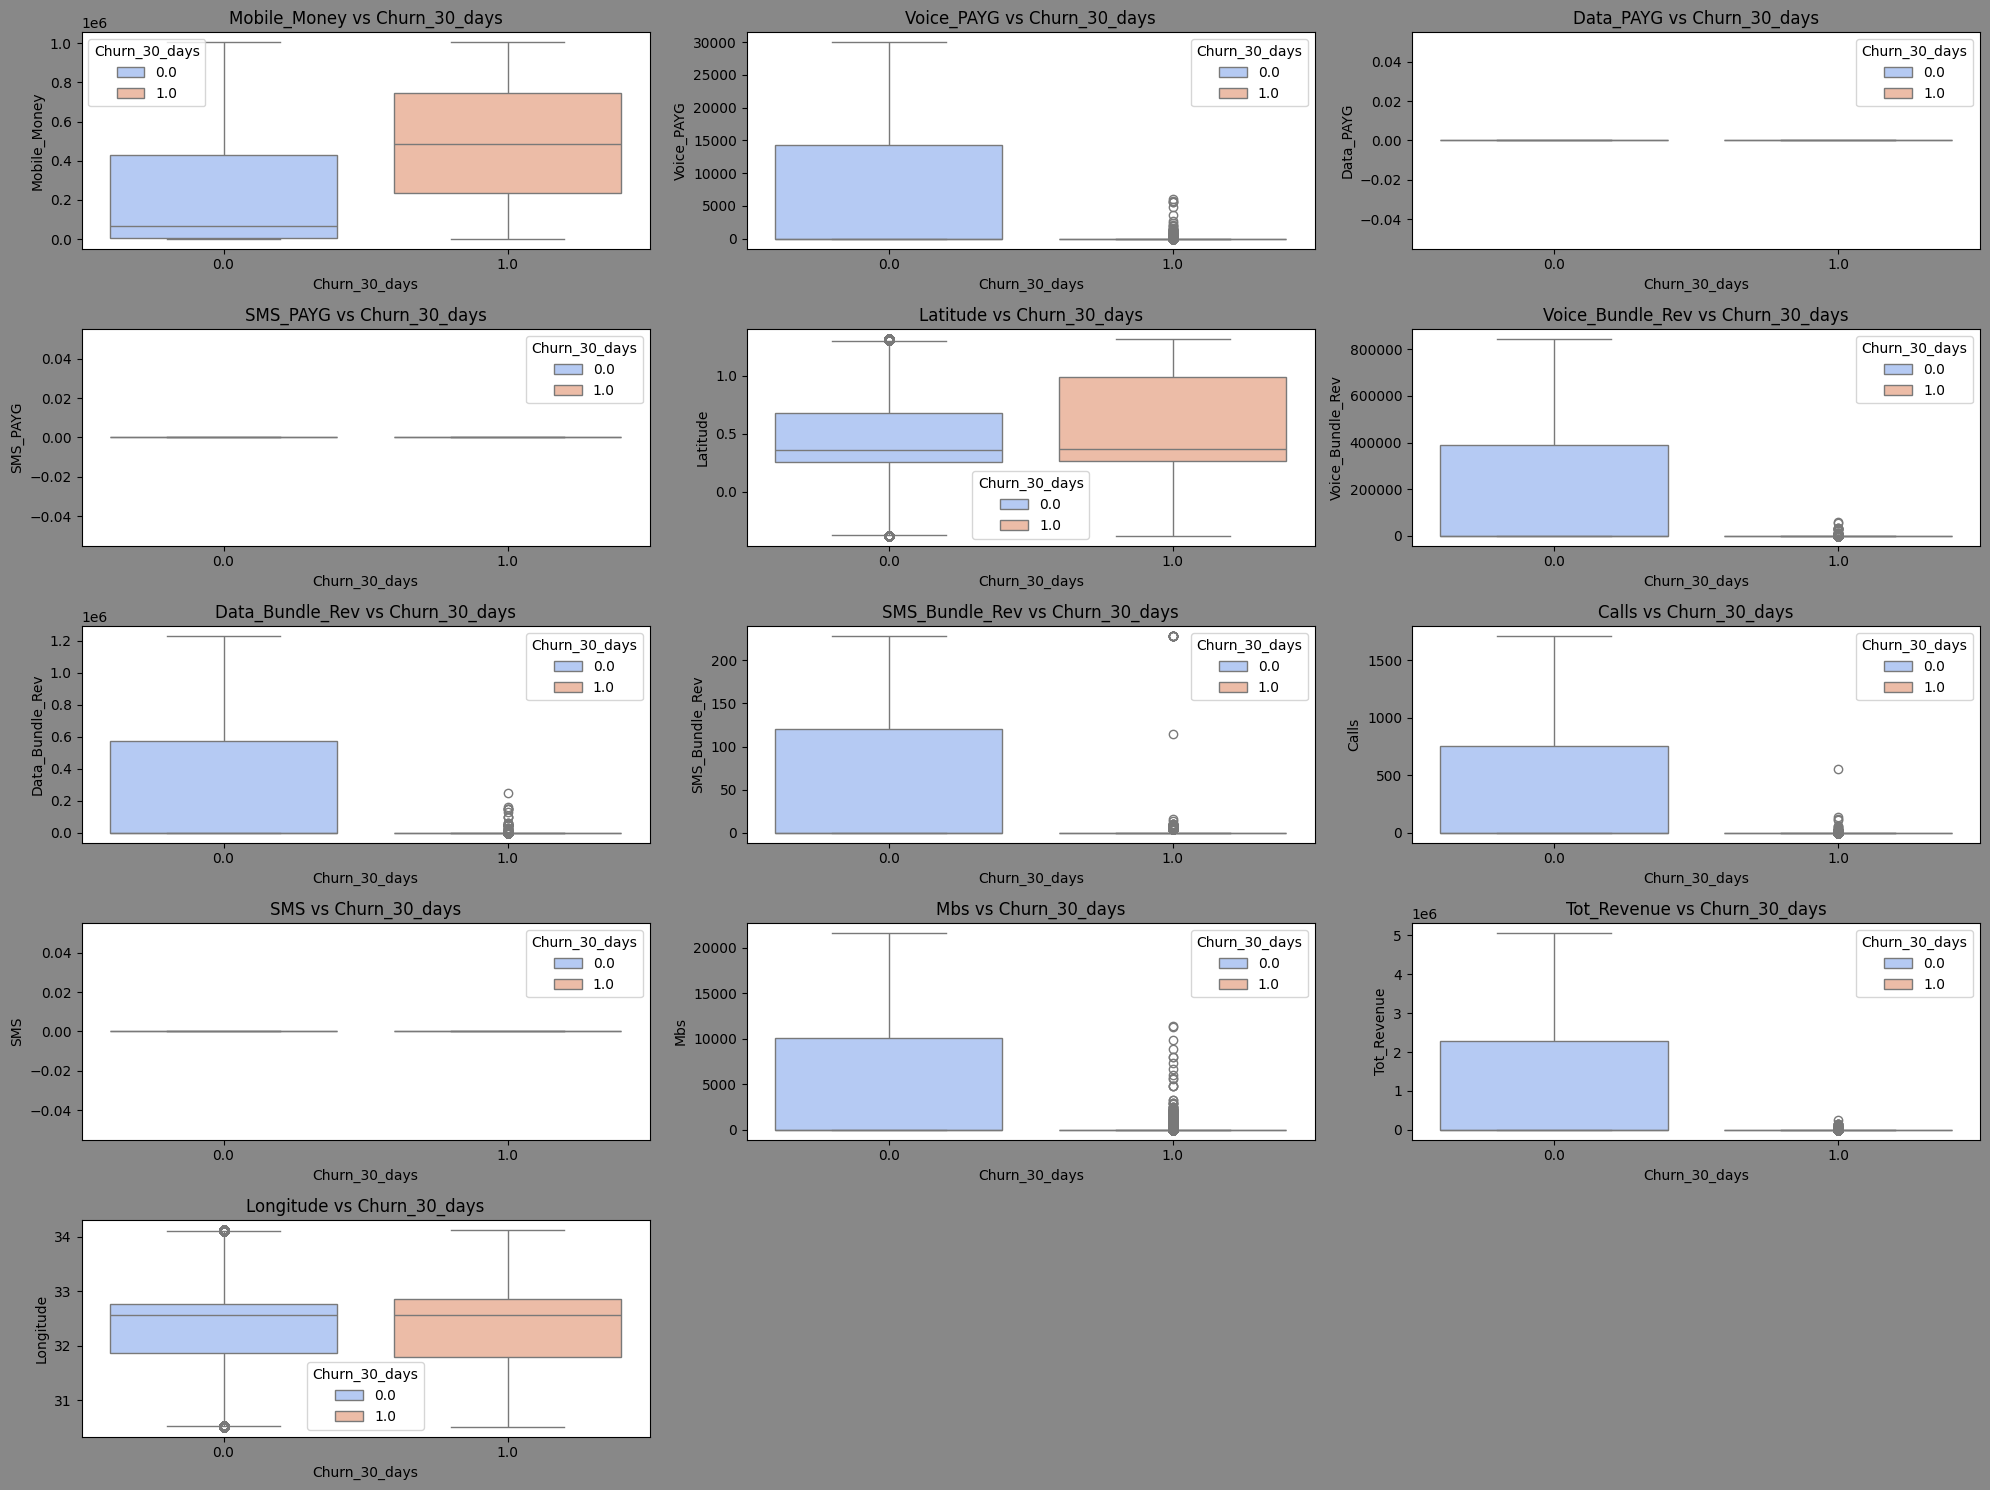

In [155]:
# Plot boxplots to visualize the relationship between 'Churn_30_days' and each continuous variable
plt.figure(figsize=(20, 15))
for i, var in enumerate(numeric_cols):
    plt.subplot(5, 3, i+1)
    sns.boxplot(x='Churn_30_days', y=var, data=df_clean, palette='coolwarm', hue='Churn_30_days')
    plt.title(f'{var} vs Churn_30_days')
plt.tight_layout()
plt.show()

In [156]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351153 entries, 0 to 2351152
Data columns (total 33 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Phone_Number      int64  
 1   Manufacturer      object 
 2   Model_Name        object 
 3   Device_Type       object 
 4   Handset_Type      object 
 5   Latitude          float64
 6   Longitude         float64
 7   Gender            object 
 8   Gross_Add         bool   
 9   Win_Backs         bool   
 10  Recon             bool   
 11  Churn_30_days     float64
 12  REC_30_Days       bool   
 13  REC_90_Days       bool   
 14  Q_Rec             bool   
 15  Q_Rec_over100mbs  bool   
 16  Age               float64
 17  Value_Segment     object 
 18  Tot_Revenue       float64
 19  Mobile_Money      float64
 20  Voice_PAYG        float64
 21  Data_PAYG         float64
 22  SMS_PAYG          float64
 23  Voice_Bundle_Rev  float64
 24  Data_Bundle_Rev   float64
 25  SMS_Bundle_Rev    float64
 26  Calls         

In [157]:
# Binary flags
df_clean['IS_NEW_SUBSCRIBER'] = df_clean['Gross_Add'].astype(bool)
df_clean['IS_RECENTLY_ACTIVE'] = (df_clean['REC_30_Days'].astype(bool) > 0).astype(bool)
df_clean['IS_BASE_ACTIVE'] = (df_clean['REC_90_Days'].astype(bool) > 0).astype(bool)
df_clean['IS_ENGAGED_USER'] = (df_clean['Q_Rec'].astype(bool) > 0).astype(bool)
df_clean['IS_HEAVY_USER'] = (df_clean['Q_Rec_over100mbs'].astype(bool) > 0).astype(bool)
df_clean['IS_WINBACK'] = (df_clean['Win_Backs'].astype(bool) > 0).astype(bool)
df_clean['IS_RECONNECTED'] = (df_clean['Recon'].astype(bool) > 0).astype(bool)


# Premium device
df_clean['IS_PREMIUM_DEVICE'] = df_clean['Manufacturer'].str.lower().isin(['apple', 'samsung', 'google']).astype(bool)

# Combine type and tech
df_clean['DEVICE_CATEGORY'] = df_clean['Device_Type'].str.lower() + '_' + df_clean['Handset_Type'].str.lower()

# Target label
df_clean['IS_CHURNED'] = df_clean['Churn_30_days'].astype(bool)


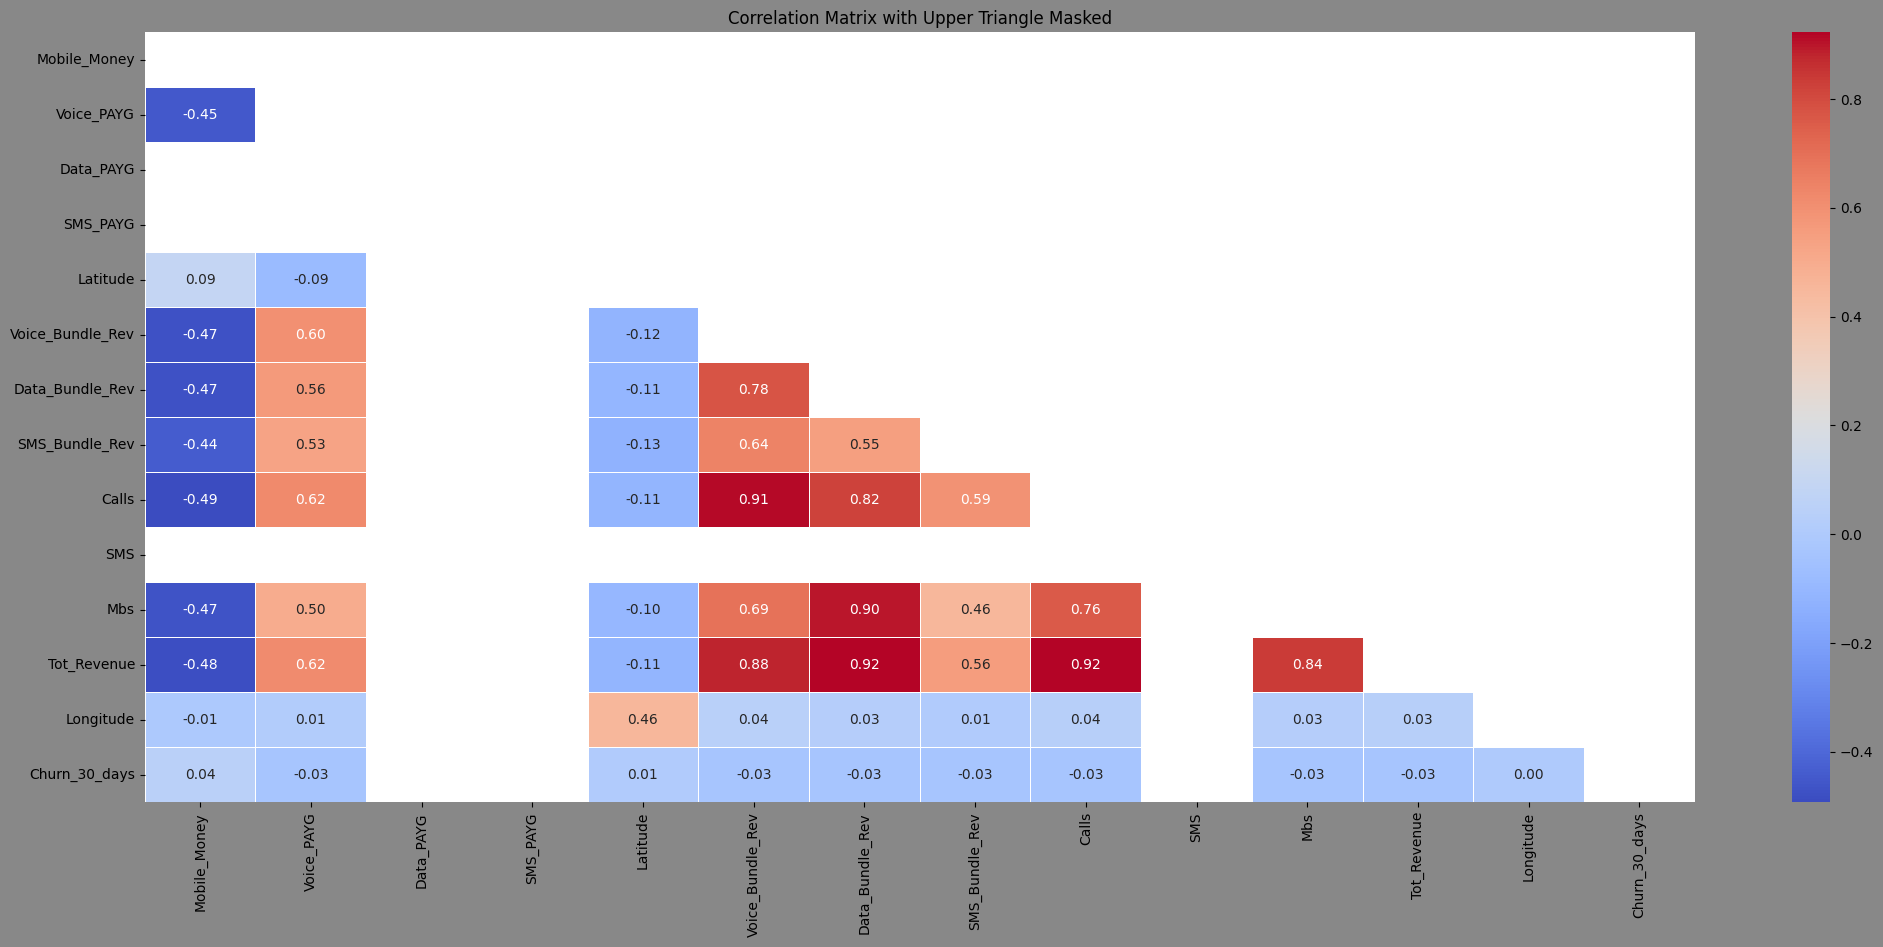

In [158]:
categorical_cols += [
    'IS_NEW_SUBSCRIBER', 'IS_RECENTLY_ACTIVE', 'IS_BASE_ACTIVE',
    'IS_ENGAGED_USER', 'IS_HEAVY_USER', 'IS_WINBACK', 'IS_RECONNECTED',
    'IS_PREMIUM_DEVICE', 'DEVICE_CATEGORY'
]
corr = df_clean[numeric_cols+['Churn_30_days']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(25, 10))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)

plt.title("Correlation Matrix with Upper Triangle Masked")
plt.show()

In [159]:
def FunctionAnova(inpData, TargetVariable, ContinuousPredictorList):
    from scipy.stats import f_oneway

    SelectedPredictors = []

    print('##### ANOVA Results #####\n')

    for predictor in ContinuousPredictorList:
        try:
            # Group target variable by predictor values
            group_lists = inpData.groupby(predictor)[TargetVariable].apply(list)

            # Only keep non-empty groups
            group_lists = [g for g in group_lists if len(g) > 0]

            # Continue only if there are at least 2 groups
            if len(group_lists) >= 2:
                AnovaResults = f_oneway(*group_lists)
                p_value = AnovaResults[1]

                if p_value < 0.05:
                    print(f"✅ {predictor} is correlated with {TargetVariable} | P-Value: {p_value:.4f}")
                    SelectedPredictors.append(predictor)
                else:
                    print(f"❌ {predictor} is NOT correlated with {TargetVariable} | P-Value: {p_value:.4f}")
            else:
                print(f"🔃 {predictor} skipped — only one group found.")

        except Exception as e:
            print(f"❌ {predictor} skipped due to error: {e}")

    return SelectedPredictors


In [165]:
selected_features_cont = FunctionAnova(inpData=df_clean, TargetVariable='IS_CHURNED',  ContinuousPredictorList=numeric_cols)

##### ANOVA Results #####

✅ Mobile_Money is correlated with IS_CHURNED | P-Value: 0.0000
✅ Voice_PAYG is correlated with IS_CHURNED | P-Value: 0.0000
🔃 Data_PAYG skipped — only one group found.
🔃 SMS_PAYG skipped — only one group found.
✅ Latitude is correlated with IS_CHURNED | P-Value: 0.0000
❌ Voice_Bundle_Rev is NOT correlated with IS_CHURNED | P-Value: 1.0000
❌ Data_Bundle_Rev is NOT correlated with IS_CHURNED | P-Value: 1.0000
✅ SMS_Bundle_Rev is correlated with IS_CHURNED | P-Value: 0.0000
✅ Calls is correlated with IS_CHURNED | P-Value: 0.0000
🔃 SMS skipped — only one group found.
✅ Mbs is correlated with IS_CHURNED | P-Value: 0.0000
❌ Tot_Revenue is NOT correlated with IS_CHURNED | P-Value: 1.0000
✅ Longitude is correlated with IS_CHURNED | P-Value: 0.0000


In [161]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in categorical_cols:
    try:
        contingency_table = pd.crosstab(df_clean[col], df_clean['Churn_30_days'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        chi2_results.append({
            'Feature': col,
            'Chi2 Statistic': round(chi2, 4),
            'p-value': round(p, 4)
        })
    except Exception as e:
        print(f"Skipping {col} due to error: {e}")

chi2_df = pd.DataFrame(chi2_results).sort_values(by='p-value')

# Select relevant features (p < 0.05)
selected_features_cat = chi2_df[chi2_df['p-value'] < 0.05]['Feature'].tolist()

print("Significant categorical features related to Churn:")
print(chi2_df)

print("\nSelected relevant features:")
print(selected_features_cat)

Significant categorical features related to Churn:
               Feature  Chi2 Statistic  p-value
0         Manufacturer       1309.9705   0.0000
1           Model_Name        180.1458   0.0000
2          Device_Type       9486.1784   0.0000
3         Handset_Type        127.2866   0.0000
4               Gender       1014.8475   0.0000
5        Value_Segment       2599.5248   0.0000
6           Age_Groups       2823.3949   0.0000
7          REC_30_Days      11936.2548   0.0000
8          REC_90_Days       2292.6000   0.0000
9                Q_Rec       4562.0839   0.0000
10    Q_Rec_over100mbs       3122.3056   0.0000
12           Gross_Add         53.3897   0.0000
15        USED_SMSPAYG        471.4909   0.0000
18  IS_RECENTLY_ACTIVE      11936.2548   0.0000
17   IS_NEW_SUBSCRIBER         53.3897   0.0000
16            USED_SMS       1390.3789   0.0000
20     IS_ENGAGED_USER       4562.0839   0.0000
21       IS_HEAVY_USER       3122.3056   0.0000
25     DEVICE_CATEGORY      12405.386

In [162]:
df_clean['Churn_30_days'].value_counts(normalize=True) * 100

Churn_30_days
0.0    99.723332
1.0     0.276668
Name: proportion, dtype: float64

In [164]:
df_clean

,Phone_Number,Manufacturer,Model_Name,Device_Type,Handset_Type,Latitude,Longitude,Gender,Gross_Add,Win_Backs,...,IS_NEW_SUBSCRIBER,IS_RECENTLY_ACTIVE,IS_BASE_ACTIVE,IS_ENGAGED_USER,IS_HEAVY_USER,IS_WINBACK,IS_RECONNECTED,IS_PREMIUM_DEVICE,DEVICE_CATEGORY,IS_CHURNED
0,15753521664,Itel,IT2160,Phone,2G,0.629370,33.490010,F,False,False,...,False,True,True,False,False,False,False,False,phone_2g,False
1,15753678592,Itel,IT2160,Phone,2G,1.109931,33.861108,F,False,False,...,False,False,False,False,False,False,False,False,phone_2g,False
2,15753851904,Other,Other,Phone,2G,0.388625,32.149202,F,False,False,...,False,True,True,True,True,False,False,False,phone_2g,False
3,15754213376,Itel,IT2160,Phone,2G,-0.378939,30.515408,F,False,False,...,False,True,True,False,False,False,False,False,phone_2g,False
4,15754528256,Itel,IT2163,Phone,2G,0.460332,32.566113,F,False,False,...,False,False,False,False,False,False,False,False,phone_2g,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2351148,16264791808,Apple,iPhone12Pro,Smartphone,5G,0.334435,32.561241,Undocumented,False,False,...,False,True,True,False,False,False,False,True,smartphone_5g,False
2351149,16266225152,Samsung,Other,Smartphone,5G,0.320600,32.588310,Undocumented,False,False,...,False,True,True,True,True,False,False,True,smartphone_5g,False
2351150,16270080512,Samsung,Other,Tablet,5G,0.422109,32.562708,Undocumented,False,False,...,False,True,True,True,True,False,False,True,tablet_5g,False
2351151,16270200320,Samsung,Other,Smartphone,5G,0.613320,33.485770,Undocumented,False,False,...,False,True,True,True,True,False,False,True,smartphone_5g,False


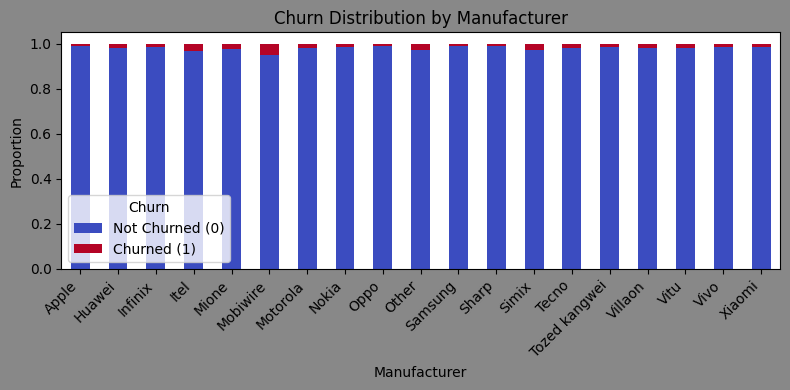

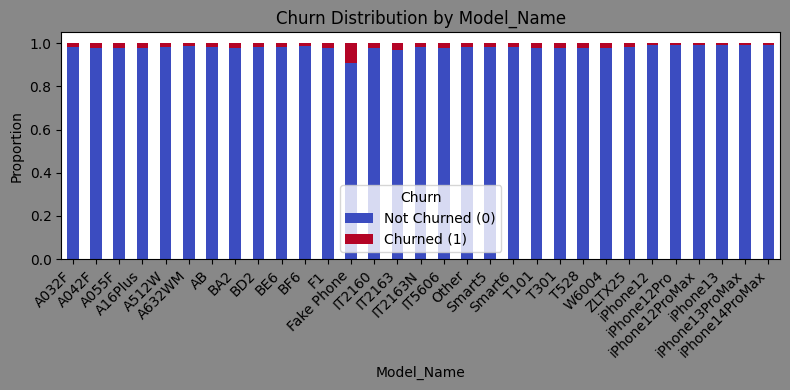

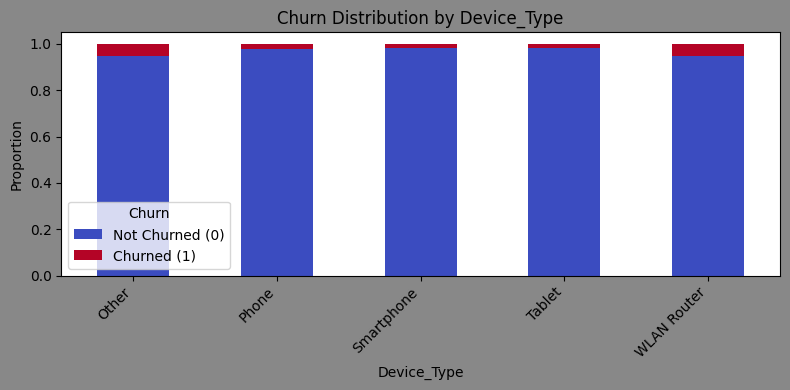

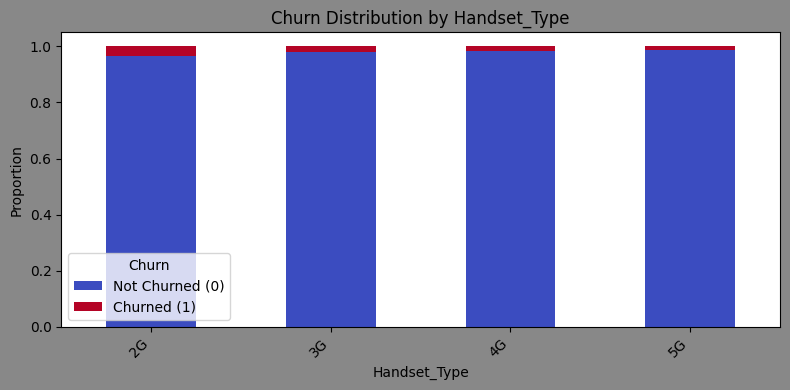

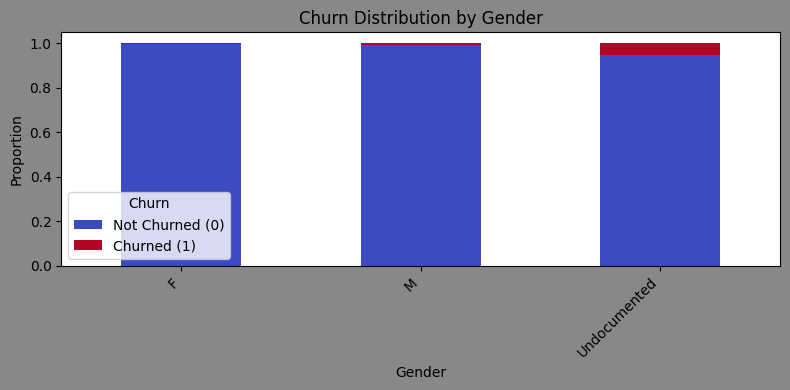

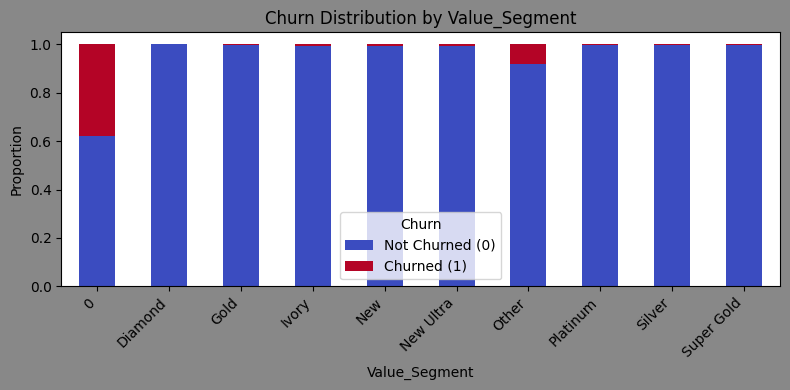

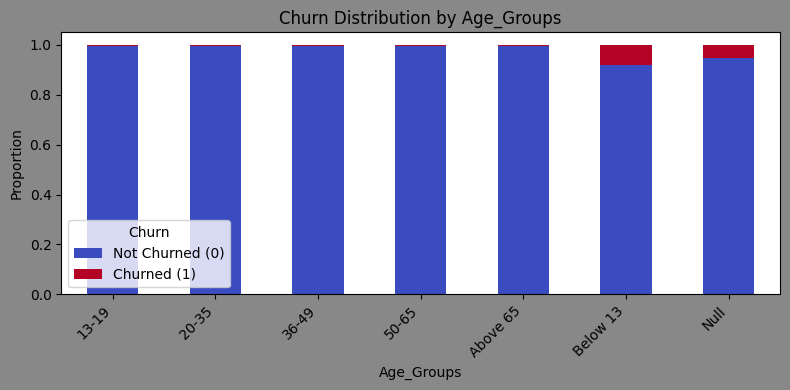

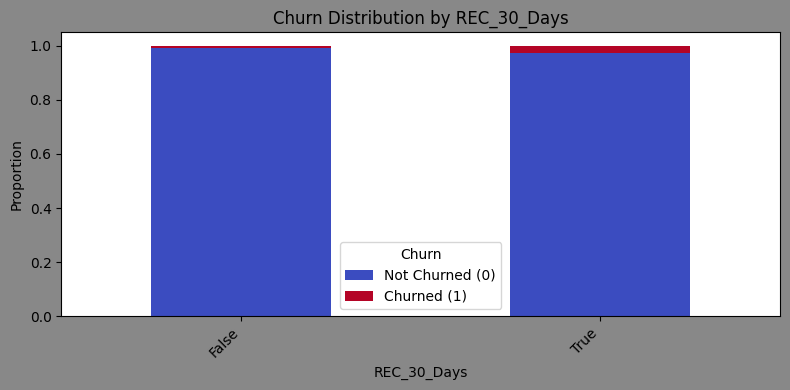

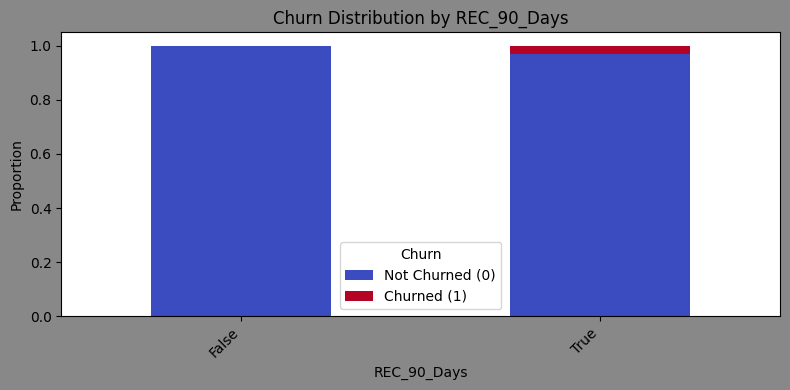

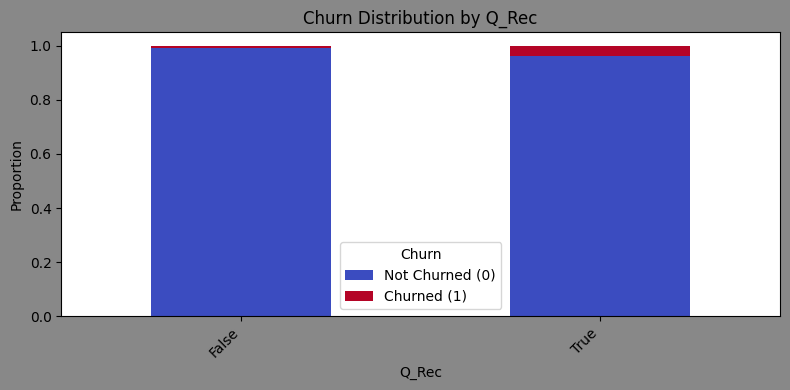

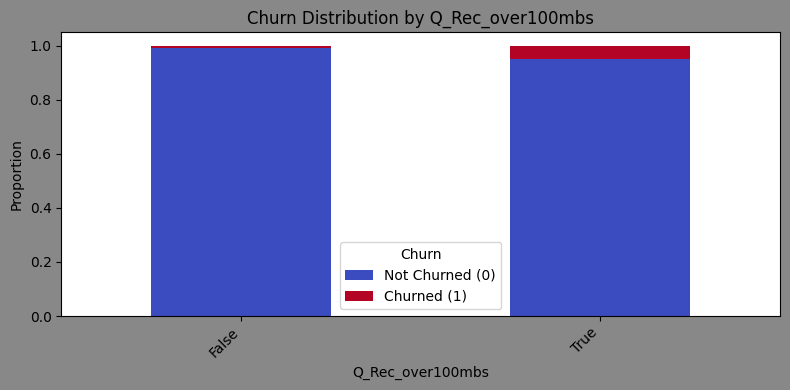

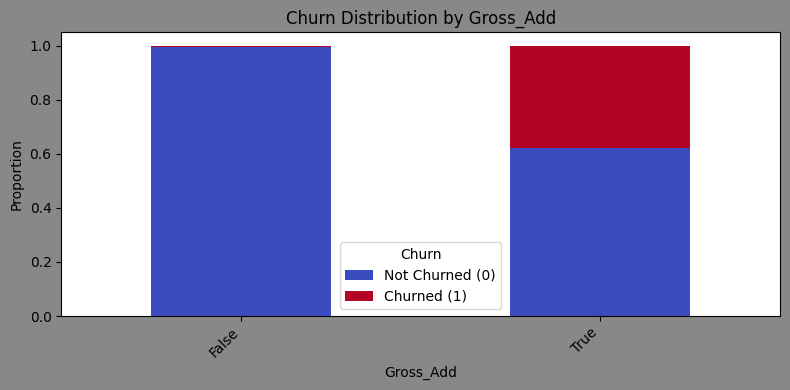

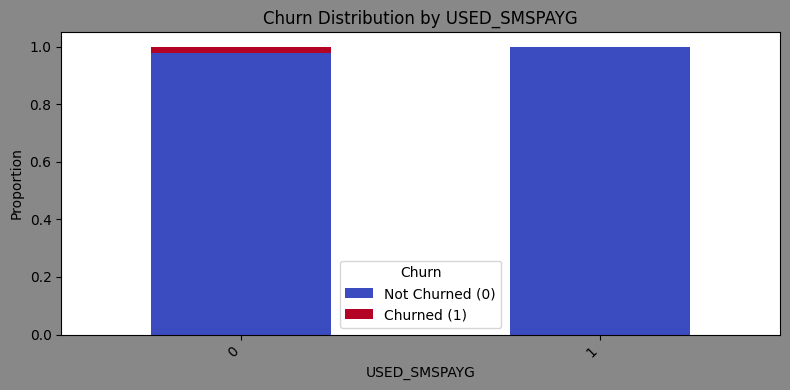

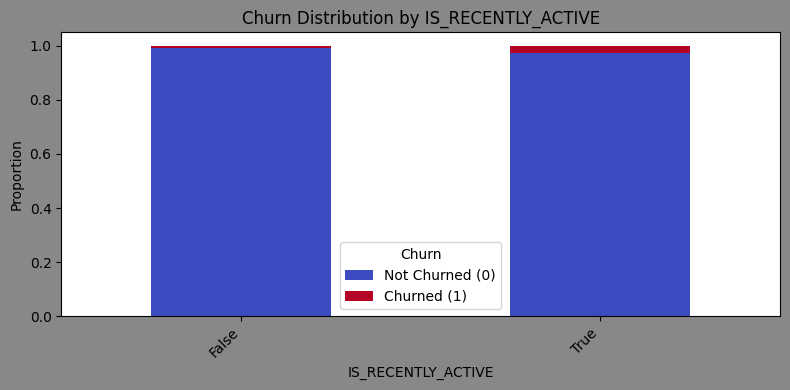

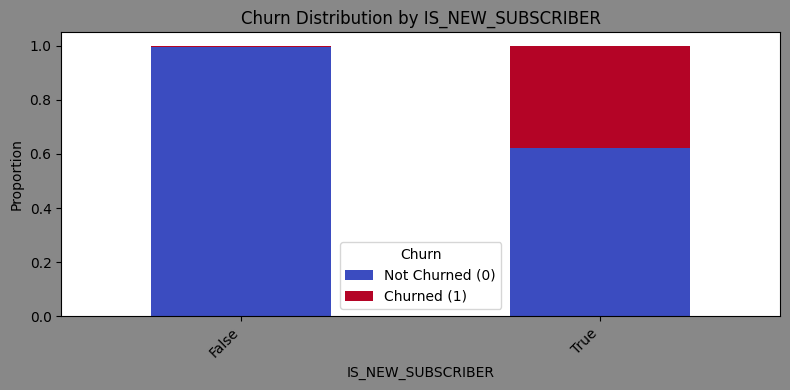

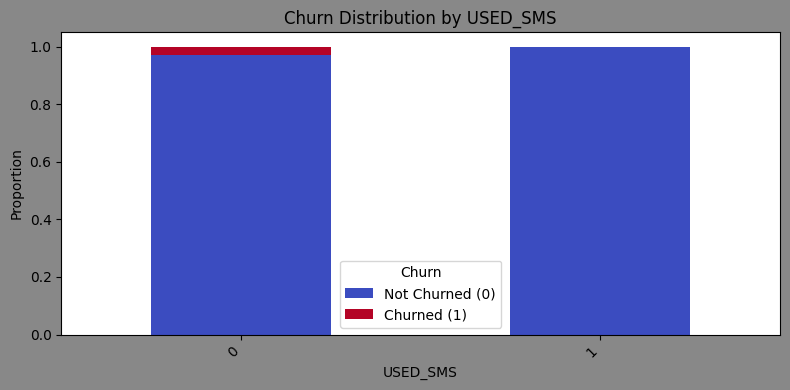

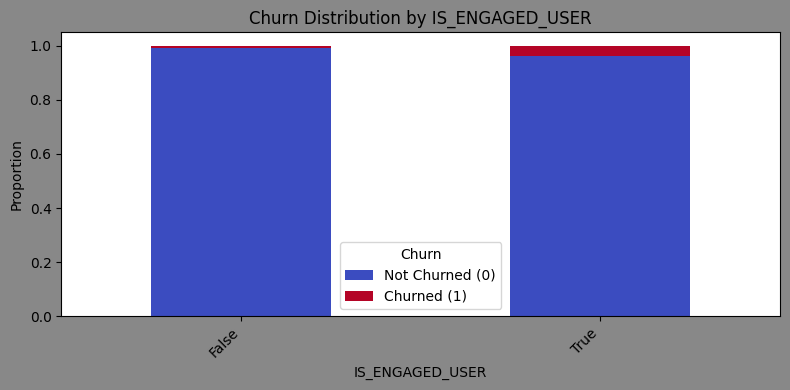

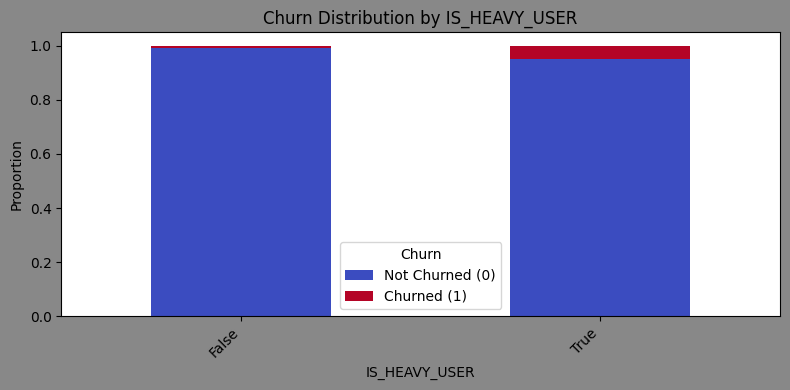

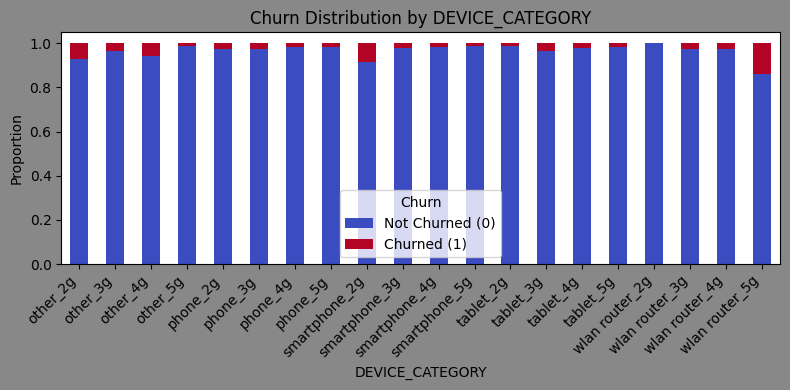

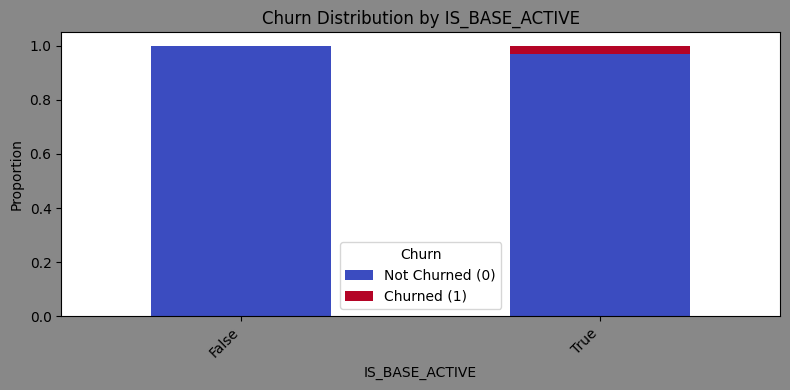

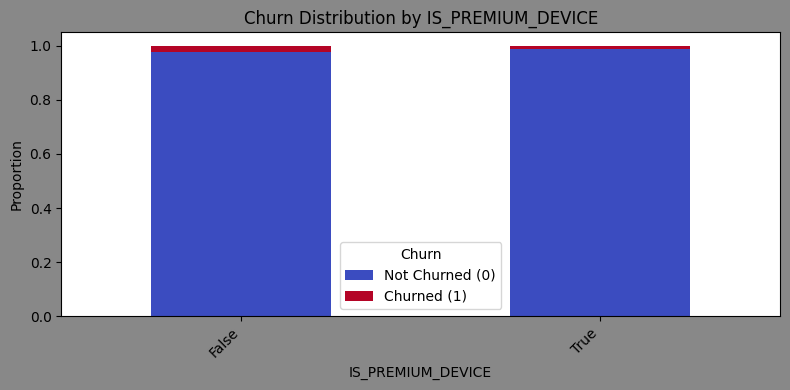

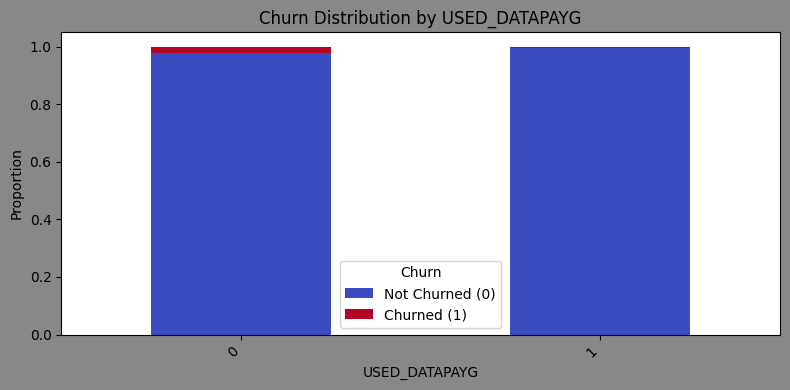

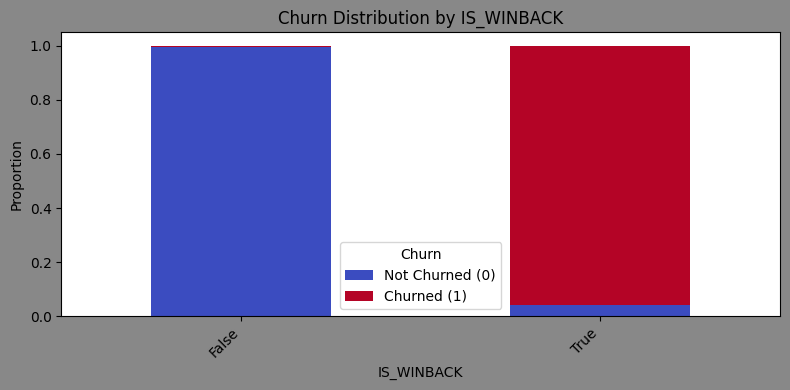

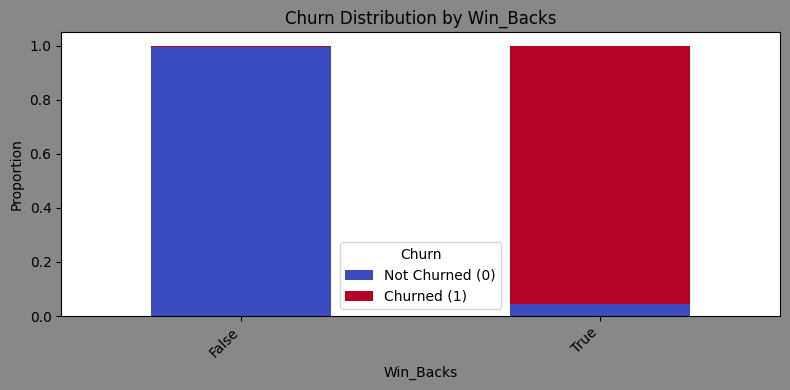

In [166]:
for col in selected_features_cat:
    if col in df_clean.columns:
        plt.figure(figsize=(8, 4))
        # Cross-tabulation with normalization by row (proportions)
        ct = pd.crosstab(df_clean[col], df_clean['IS_CHURNED'], normalize='index')
        ct.plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())
        plt.title(f'Churn Distribution by {col}')
        plt.ylabel('Proportion')
        plt.xlabel(col)
        plt.legend(title='Churn', labels=['Not Churned (0)', 'Churned (1)'])
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

### Check for Multicollinearity

In [167]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Drop target & non-numeric cols if included
X = df_clean[selected_features_cont].dropna()

# Add constant for intercept
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))


          Feature          VIF
0           const  1399.237096
5           Calls     3.239038
6             Mbs     2.436058
2      Voice_PAYG     1.794294
4  SMS_Bundle_Rev     1.706010
1    Mobile_Money     1.468182
3        Latitude     1.297997
7       Longitude     1.275309


In [168]:
selected_features = list(set(selected_features_cat + selected_features_cont))

# Selecting final columns
DataForML_Churn=df_clean[selected_features]
DataForML_Churn.head()

,IS_NEW_SUBSCRIBER,REC_30_Days,Q_Rec_over100mbs,Mobile_Money,IS_PREMIUM_DEVICE,Age_Groups,SMS_Bundle_Rev,USED_SMSPAYG,Gross_Add,USED_DATAPAYG,...,REC_90_Days,Device_Type,Gender,IS_WINBACK,Manufacturer,Q_Rec,IS_ENGAGED_USER,Handset_Type,IS_RECENTLY_ACTIVE,USED_SMS
0,False,True,False,458907.0,False,20-35,0.0,0,False,0,...,True,Phone,F,False,Itel,False,False,2G,True,0
1,False,False,False,415816.0,False,36-49,0.0,0,False,0,...,False,Phone,F,False,Itel,False,False,2G,False,0
2,False,True,True,40825.0,False,20-35,228.0,0,False,0,...,True,Phone,F,False,Other,True,True,2G,True,1
3,False,True,False,2421.0,False,36-49,228.0,0,False,0,...,True,Phone,F,False,Itel,False,False,2G,True,1
4,False,False,False,847882.0,False,20-35,0.0,0,False,0,...,False,Phone,F,False,Itel,False,False,2G,False,0


## Model Creation & Evaluation

In [170]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# One-hot encode these
df_encoded = pd.get_dummies(df_clean[selected_features], columns=selected_features_cat, drop_first=True)

# Define X and y
X = df_encoded.dropna()
y = df_clean.loc[X.index, 'IS_CHURNED'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)


In [171]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply only to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 IS_CHURNED
0    1553649
1      29187
Name: count, dtype: int64

After SMOTE:
 IS_CHURNED
0    1553649
1    1553649
Name: count, dtype: int64



🔧 Training model: Logistic

Confusion Matrix (Validation):


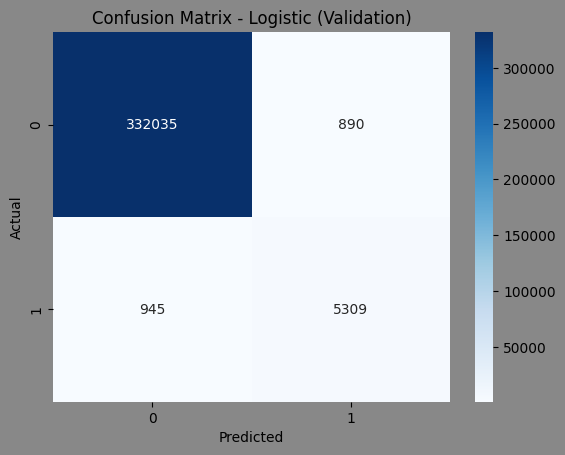


Classification Report (Validation):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.86      0.85      0.85      6254

    accuracy                           0.99    339179
   macro avg       0.93      0.92      0.92    339179
weighted avg       0.99      0.99      0.99    339179


Confusion Matrix (Test):


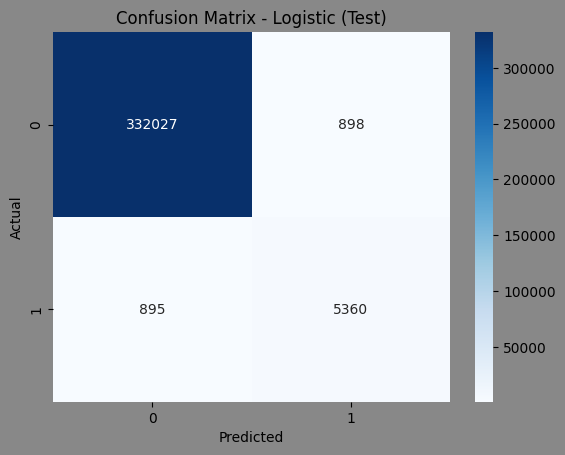


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.86      0.86      0.86      6255

    accuracy                           0.99    339180
   macro avg       0.93      0.93      0.93    339180
weighted avg       0.99      0.99      0.99    339180



🔧 Training model: Decision Tree

Confusion Matrix (Validation):


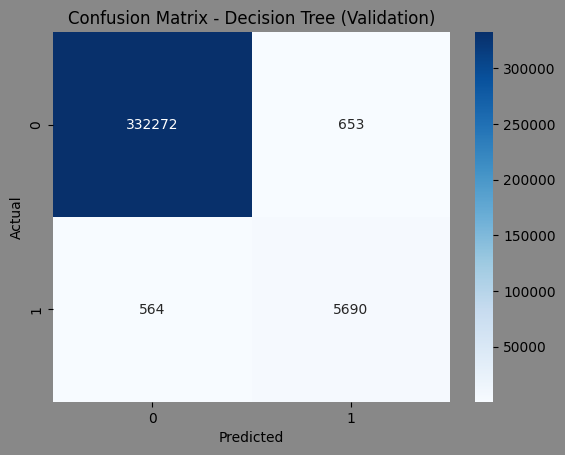


Classification Report (Validation):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.90      0.91      0.90      6254

    accuracy                           1.00    339179
   macro avg       0.95      0.95      0.95    339179
weighted avg       1.00      1.00      1.00    339179


Confusion Matrix (Test):


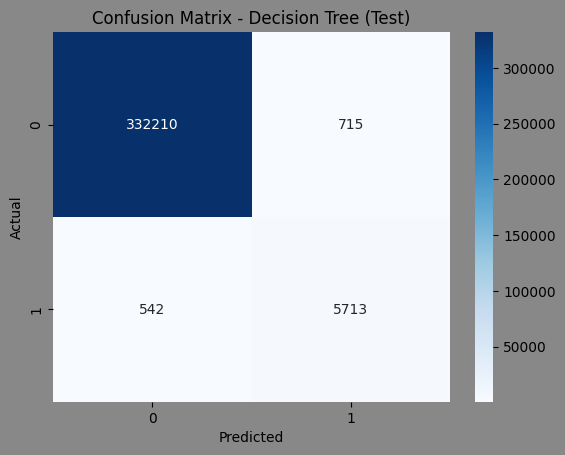


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.89      0.91      0.90      6255

    accuracy                           1.00    339180
   macro avg       0.94      0.96      0.95    339180
weighted avg       1.00      1.00      1.00    339180



🔧 Training model: Random Forest

Confusion Matrix (Validation):


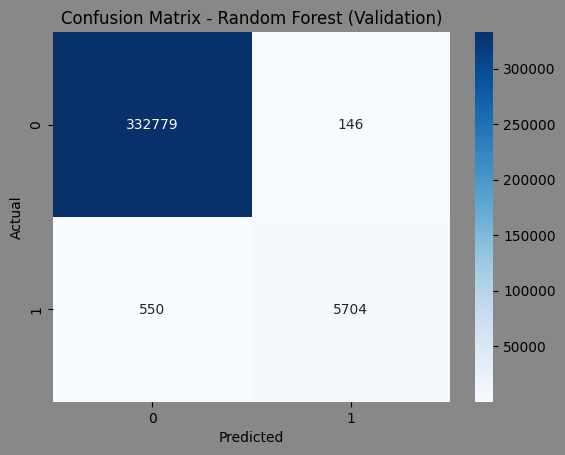


Classification Report (Validation):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.98      0.91      0.94      6254

    accuracy                           1.00    339179
   macro avg       0.99      0.96      0.97    339179
weighted avg       1.00      1.00      1.00    339179


Confusion Matrix (Test):


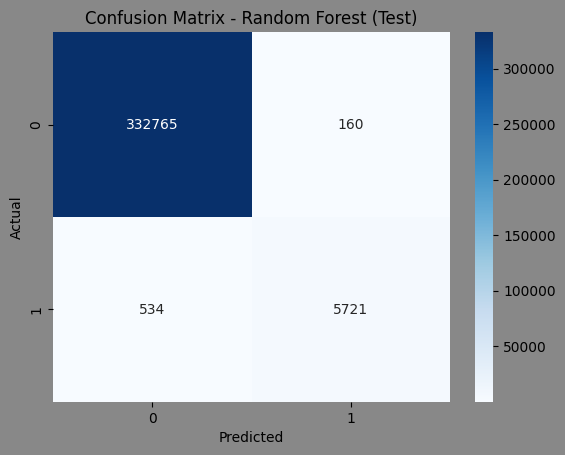


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.97      0.91      0.94      6255

    accuracy                           1.00    339180
   macro avg       0.99      0.96      0.97    339180
weighted avg       1.00      1.00      1.00    339180



🔧 Training model: XGBoost

Confusion Matrix (Validation):


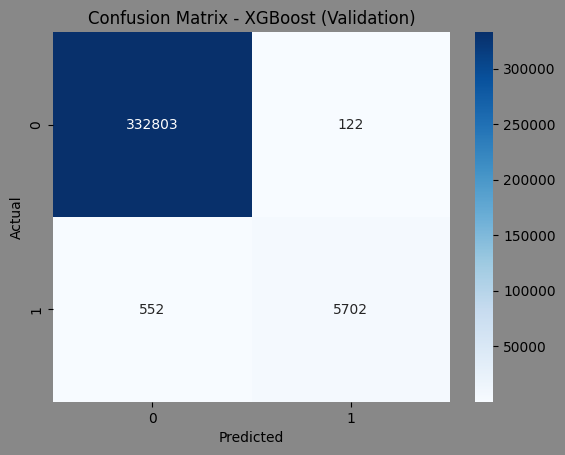


Classification Report (Validation):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.98      0.91      0.94      6254

    accuracy                           1.00    339179
   macro avg       0.99      0.96      0.97    339179
weighted avg       1.00      1.00      1.00    339179


Confusion Matrix (Test):


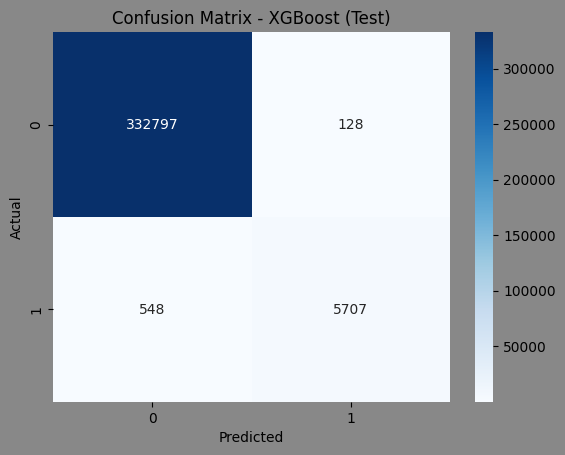


Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.98      0.91      0.94      6255

    accuracy                           1.00    339180
   macro avg       0.99      0.96      0.97    339180
weighted avg       1.00      1.00      1.00    339180




In [172]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

best_model = None
best_score = 0
results = []
models = [
    LogisticRegression(max_iter=1000),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42),
    XGBClassifier(use_label_encoder=False, eval_metric='logloss')
]

model_names = ['Logistic', 'Decision Tree', 'Random Forest', 'XGBoost']

# Loop through models
for model, name in zip(models, model_names):
    print(f"\n====================================================================")
    print(f"🔧 Training model: {name}\n")
    model.fit(X_train_smote, y_train_smote)

    # Predict on validation and test sets
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # Probabilities (for ROC AUC)
    if hasattr(model, 'predict_proba'):
        y_val_prob = model.predict_proba(X_val)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_val_prob = model.decision_function(X_val)
        y_test_prob = model.decision_function(X_test)

    # Store metrics
    results.append({
        'Model': name,

        # Validation Metrics
        'Val Accuracy': accuracy_score(y_val, y_val_pred),
        'Val Precision': precision_score(y_val, y_val_pred),
        'Val Recall': recall_score(y_val, y_val_pred),
        'Val F1': f1_score(y_val, y_val_pred),
        'Val ROC AUC': roc_auc_score(y_val, y_val_prob),

        # Test Metrics
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
        'Test ROC AUC': roc_auc_score(y_test, y_test_prob)
    })

    print("Confusion Matrix (Validation):")
    sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name} (Validation)")    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("\nClassification Report (Validation):")
    print(classification_report(y_val, y_val_pred))

    print("\nConfusion Matrix (Test):")
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name} (Test)")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    print(f"====================================================================\n")


    # Save best model by Val F1
    if f1_score(y_val, y_val_pred) > best_score:
        best_model = model
        best_score = f1_score(y_val, y_val_pred)
        best_model_name = name
        joblib.dump(model, f'best_model_SMOTE_{name.replace(" ", "_")}.pkl')


In [173]:

# Create and show results table
results_df = pd.DataFrame(results).sort_values(by='Val F1', ascending=False)
print("\n📊 Model Comparison Summary (Validation and Test):")
display(results_df)

print(f"\n✅ Best model saved: {best_model_name} (Validation F1 = {best_score:.4f})")



📊 Model Comparison Summary (Validation and Test):


,Model,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC
3,XGBoost,0.998013,0.979052,0.911736,0.944196,0.997427,0.998007,0.978063,0.912390,0.944086,0.997623
2,Random Forest,0.997948,0.975043,0.912056,0.942498,0.982503,0.997954,0.972794,0.914628,0.942815,0.983685
1,Decision Tree,0.996412,0.897052,0.909818,0.903390,0.953928,0.996294,0.888768,0.913349,0.900891,0.955601
0,Logistic,0.994590,0.856428,0.848897,0.852646,0.986730,0.994714,0.856504,0.856914,0.856709,0.987500



✅ Best model saved: XGBoost (Validation F1 = 0.9442)


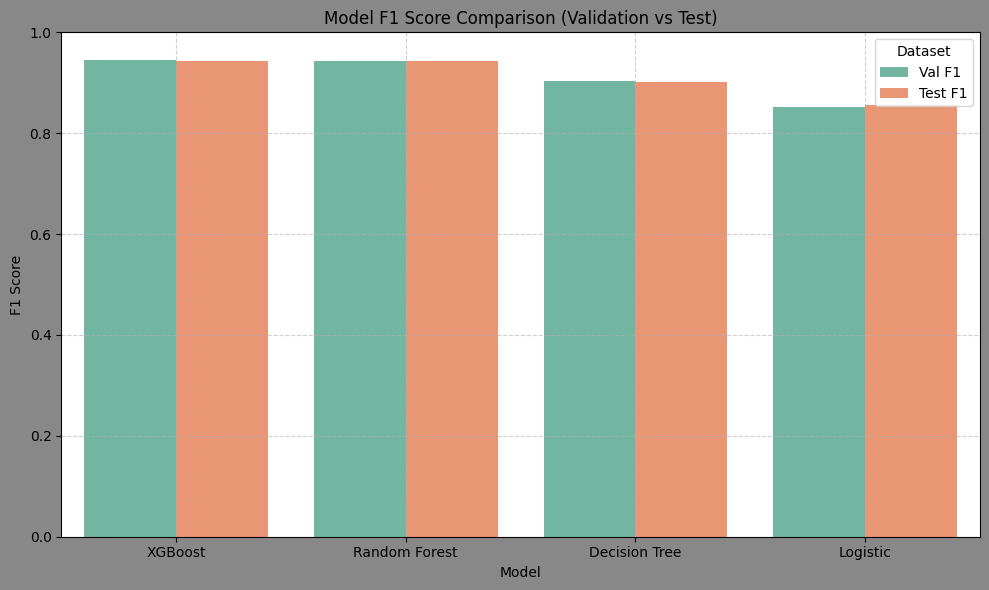

In [174]:
# Melt for seaborn plotting
plot_df = results_df.melt(id_vars='Model', value_vars=['Val F1', 'Test F1'], var_name='Dataset', value_name='F1 Score')

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='Model', y='F1 Score', hue='Dataset', palette='Set2')
plt.title('Model F1 Score Comparison (Validation vs Test)')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [175]:
from sklearn.metrics import roc_curve, auc

def plot_roc(models, model_names, X_val, y_val):
    plt.figure(figsize=(10, 8))
    
    for model, name in zip(models, model_names):
        # Get predicted probabilities (probability of class 1)
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_val)[:, 1]
        else:
            y_probs = model.decision_function(X_val)  # for SVMs

        fpr, tpr, _ = roc_curve(y_val, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('ROC Curve Comparison')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()


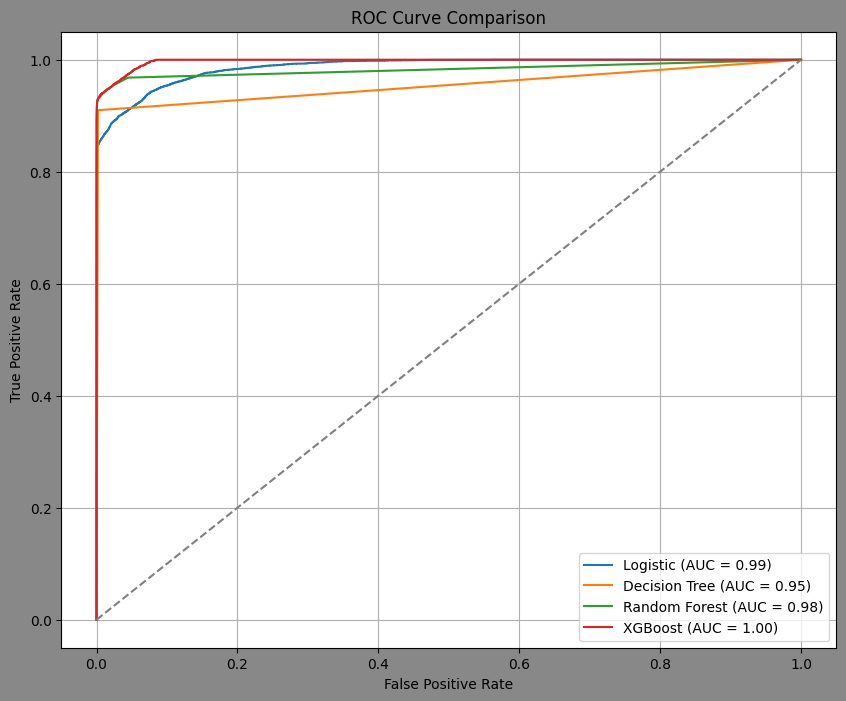

In [176]:
plot_roc(models, model_names, X_val, y_val)

> The ROC curve comparison clearly shows that the XGBoost model outperforms the others with an AUC of 1.00, indicating perfect classification performance. Logistic regression also performs strongly (AUC = 0.99), while the decision tree lags slightly behind (AUC = 0.95).

## Hyperparameter Tuning for XGBoost

In [180]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(10, 100),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'min_child_weight': randint(1, 10)
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,  # number of combinations to try
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit to SMOTE-balanced training set
random_search.fit(X_train_smote, y_train_smote)

# Best model and parameters
best_xgb = random_search.best_estimator_
print("✅ Best Parameters Found:\n", random_search.best_params_)

y_val_pred = best_xgb.predict(X_val)
print("\n📊 Validation Performance:\n")
print(classification_report(y_val, y_val_pred))

y_test_pred = best_xgb.predict(X_test)
print("\n📊 Test Performance:\n")
print(classification_report(y_test, y_test_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Best Parameters Found:
 {'colsample_bytree': np.float64(0.6028265220878869), 'gamma': np.float64(0.11531212520707879), 'learning_rate': np.float64(0.16743239807751675), 'max_depth': 9, 'min_child_weight': 3, 'n_estimators': 64, 'subsample': np.float64(0.9932923543227152)}

📊 Validation Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.98      0.91      0.94      6254

    accuracy                           1.00    339179
   macro avg       0.99      0.95      0.97    339179
weighted avg       1.00      1.00      1.00    339179


📊 Test Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    332925
           1       0.98      0.91      0.94      6255

    accuracy                           1.00    339180
   macro avg       0.99      0.95      0.97    339180
weighted avg   

## Feature Importance

In [181]:
def plot_top_features(model, feature_names, top_n=20):
    # Get importance and sort
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Take only top N
    top_df = importance_df.head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_df, y='Feature', x='Importance', palette='viridis')
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.show()

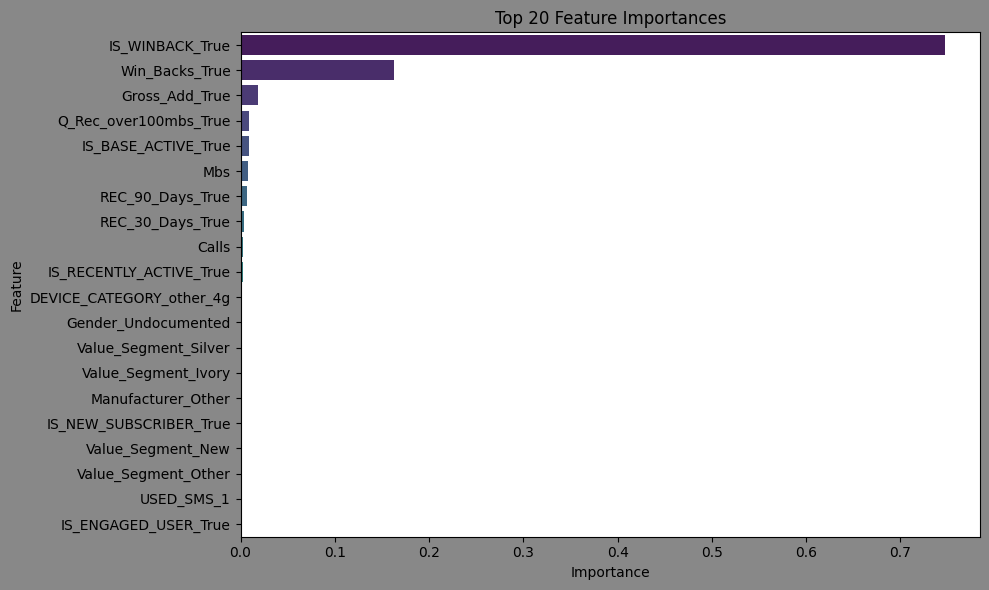

In [182]:
# model_path = f'best_model_SMOTE_{best_model_name.replace(" ", "_")}.pkl'
# feature_names = X_train.columns.tolist() 

plot_top_features(best_xgb, X_train_smote.columns, top_n=20)